# Meteo: Incoming shortwave radiation (SW_IN) (2006-2025)


**Author**: Lukas Hörtnagl (holukas@ethz.ch)


# About this notebook

Overview of the gap-filled incoming shortwave radiation product of CH-LAE. The product is produced
by `10_METEO/30_PRODUCTS/01_METEO_SW_IN_2004-2025.ipynb`; this notebook computes and corrects
nothing, it only describes what was exported.

**Columns of the product**

- `SW_IN_T1_47_1_gfXG` — incoming shortwave radiation (W m⁻²), continuous, gap-filled,
  non-negative, and exactly zero at night
- `FLAG_SW_IN_T1_47_1_ISFILLED` — `0` = measured, `1` = XGBoost model, `2` = timestamp-only
  fallback model, `3` = nighttime gap set to zero by physics. There is no code `4`

**One column, no homogenised variant.** Unlike `TA`, this series carries no second value column.
The 21 January 2016 acquisition change replaced the logger but not the sensor — every surviving
logger program reads the same Kipp & Zonen CNR1 through the same calibration — and the December
2021 replacement of the radiometer itself did not move the level either. *Sensor continuity*
below re-derives both results on every run rather than restating them.

::: {.callout-note title="Three things that make radiation different from temperature"}

- **Half the record is exactly zero.** Nights are zero by physics, not by measurement, and they
  are 48 % of all half-hours. A mean over all records is therefore as much a statement about day
  length as about the sky, and a distribution over all records is dominated by a spike at zero.
  Everything distributional below is computed on **daylight half-hours only**, and the sums are
  reported as daily and annual totals, which have no such ambiguity.
- **The quantity is bounded from above.** Potential radiation — what the sun delivers at this
  latitude on this date with no atmosphere — is astronomical and cannot drift, so it makes a
  natural denominator. The **clearness index**, the ratio of the two, separates the state of the
  sky from the position of the sun and is what the seasonality and threshold sections use.
- **Errors are multiplicative.** A sensitivity a few per cent wrong reads a few per cent low at
  every irradiance, so comparisons against a reference are ratios below, never differences.

:::

**Timestamps.** The product is stored on `TIMESTAMP_MIDDLE` at 30 minutes, so a record labelled
`13:15` is the average over `13:00` to `13:30`. Wherever a single record is quoted, its averaging
window is reported instead of its timestamp.

**Three conventions used throughout**

- *Extremes are taken from measured records only.* A gap-filled value is a model result and cannot
  set a record. Means, counts and totals use the full series, which is why the gap-filled share of
  each year is reported before any statistic.
- *Yearly means are means of yearly means.* The overall mean averages the yearly means, so every
  year carries the same weight. The mean over all records is printed next to it for comparison.
- *The record starts in 2006.* The product begins in 2004, but the radiometer was not wired to
  this tower's logger until 14 September 2005, so 2004 is entirely modelled and 2005 is 30 %
  measured. Neither can be compared with a measured year.


</br>


# Settings


In [1]:
# Identity of the series in the product file. Unlike TA there is one value column: this series is
# homogeneous across both of its hardware changes, which the sensor-continuity section re-derives.
varname = 'SW_IN_T1_47_1_gfXG'
flagname = 'FLAG_SW_IN_T1_47_1_ISFILLED'
var = "SW_IN"  # name shown in plots
units = r"$\mathrm{W\ m^{-2}}$"
units_plain = "W m-2"
units_sum = r"$\mathrm{MJ\ m^{-2}}$"

# What the fill flag codes mean, taken from the notebook that produced the product
# (10_METEO/30_PRODUCTS/01). Code 3 is not an estimate: the sun is below the horizon and the value
# is zero by physics. There is no code 4 - short-gap interpolation stayed off, because a second
# radiation measurement was available in both gap-filling periods.
FLAG_LEGEND = {
    0: 'measured',
    1: 'XGBoost model (daytime gap)',
    2: 'timestamp-only fallback model (daytime gap)',
    3: 'nighttime gap, set to zero by physics',
}
# Codes that no model produced, for the "not modelled" share reported beside the measured share.
NOT_MODELLED = [0, 3]

# Period covered by this overview. The product starts in 2004, but the radiometer was connected to
# this tower's logger on 14 September 2005: 2004 is entirely modelled and 2005 is 30 % measured.
FIRST_YEAR = 2006
LAST_YEAR = 2025

# Analysis parameters.
N_RECENT_YEARS = 10  # length of the recent period in the period means
N_RANKED = 5  # number of years listed as brightest and dullest
N_EXTREMES = 10  # number of records listed in the extremes tables
REFERENCE_START_YEAR = FIRST_YEAR  # reference period for all anomalies
REFERENCE_END_YEAR = LAST_YEAR

# Site coordinates and timezone, used for potential radiation. It depends on nothing but the clock
# and the location, so every quantity derived from it introduces no further measurement.
# Same values as 10_METEO/30_PRODUCTS.
SITE_LAT = 47.478333  # CH-LAE
SITE_LON = 8.364389
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # CET (winter time), the timezone the product is stored in

# Daylight is defined from potential radiation rather than from the measurement, so the definition
# does not depend on the series being described. 20 W m-2 of potential radiation excludes the
# twilight half-hours in which a ratio against it is dominated by its own denominator.
DAYLIGHT_POTRAD = 20.0

# Clearness-index thresholds for the day-type counts. Chosen from the record's own daily
# distribution (its 25th and 75th percentiles fall near these), so both classes are populated in
# every year rather than only in unusual ones.
KT_CLEAR = 0.65      # a day at or above this is counted as clear
KT_OVERCAST = 0.25   # a day at or below this is counted as overcast

# Physical limits for the integrity check. The upper limit is above the solar constant, so it
# catches a broken unit or a failed gap-filling rather than an unusual bright half-hour.
LIMITS = (0.0, 1400.0)

# Reference: MeteoSwiss Laegern, 2.5 km from the tower. Written by 10_METEO/10_REFERENCE.
REFPATH = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
           r"\workflow\10_METEO\10_REFERENCE\MeteoSwiss_LAE_30MIN_2004-2025.parquet")
REFCOL = "SW_IN_LAE_MS"
# That station's radiation instrumentation was rebuilt in October 2010 and its global radiation
# steps by about 5 % there. It is a property of the reference, not of the tower - see
# 30_PRODUCTS/RADIATION_SENSOR_CONTINUITY.ipynb - and the comparison section splits on it rather
# than averaging across it.
REF_STEP_YEAR = 2011  # first full year after the reference station changed

# The appendix draws two figures per year. Switch it off for a quick run.
SHOW_PER_YEAR_DETAIL = True


# Imports


In [2]:
import calendar
import importlib.metadata
import textwrap
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from scipy.stats import kendalltau, theilslopes

import diive as dv
from diive.core.io.files import save_parquet, load_parquet
from diive.core.plotting.cumulative import CumulativeYear
from diive.core.plotting.bar import LongtermAnomaliesYear

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")


diive version: v0.91.0


# Helpers


In [3]:
def per_year(s, how='mean'):
    """Aggregate `s` to one value per year, indexed by the year number instead of by a timestamp."""
    out = s.resample('YE').agg(how)
    out.index = out.index.year
    out.index.name = 'YEAR'
    return out


def per_year_month(s, how='mean', month_names=True):
    """Aggregate `s` to a table of YEAR (rows) by MONTH (columns)."""
    out = s.groupby([s.index.year, s.index.month]).agg(how).unstack()
    out.index.name = 'YEAR'
    if month_names:
        out.columns = [calendar.month_abbr[m] for m in out.columns]
    return out


def tabcap(text, width=100):
    """Print a table caption. Called by `styled`, so no table can be shown without one."""
    print(textwrap.fill(f"Table — {text}", width) + "\n")


def figcap(fig, text, width=125):
    """Place a caption under a figure. Call after the last axes of that figure is drawn.

    A figure drawn with a layout engine makes room for a caption by itself. The figures pandas and
    diive build have no engine, and a caption placed in them lands on top of the tick labels. For
    those the figure is extended downwards by the height of the caption and every axes is moved up
    by the same amount, so the drawing keeps its size and position and the caption gets a free
    strip below it.
    """
    width = min(width, max(40, int(14.5 * fig.get_size_inches()[0])))
    caption = textwrap.fill(f"Figure — {text}", width)
    # An engine that still lays the figure out at draw time can make room for a caption itself.
    # plt.tight_layout() does NOT leave one: it executes once and leaves a PlaceHolderLayoutEngine
    # that never runs again, so a caption handed to supxlabel there lands on top of the tick
    # labels. Those figures take the manual branch below.
    _engine = fig.get_layout_engine()
    if _engine is not None and type(_engine).__name__ != 'PlaceHolderLayoutEngine':
        fig.supxlabel(caption, fontsize=9, ha='left', x=0.005)
        return
    lines = len(caption.splitlines())
    extra = 0.17 * lines + 0.12  # inches, one caption line is about 0.17 in at fontsize 9
    width_in, height_in = fig.get_size_inches()
    fig.set_size_inches(width_in, height_in + extra)
    keep = height_in / (height_in + extra)
    offset = extra / (height_in + extra)
    for ax in fig.axes:
        pos = ax.get_position()
        ax.set_position([pos.x0, offset + pos.y0 * keep, pos.width, pos.height * keep])
    fig.text(0.005, 0.01, caption, fontsize=9, ha='left', va='bottom')


def window(tsmid):
    """The averaging window of a 30MIN record stored on TIMESTAMP_MIDDLE, as text."""
    start = tsmid - pd.Timedelta('15min')
    end = tsmid + pd.Timedelta('15min')
    return f"{start:%d %b %Y}, {start:%H:%M} to {end:%H:%M}"


def styled(data, caption, fmt="{:.1f}", subset=None, cmap="YlOrRd", axis=0, center=False):
    """`data` as a table with a caption, fixed decimals and a colour scale over its values.

    The default colour map is sequential rather than diverging: radiation has a physical zero and
    no meaningful midpoint, so a red/blue scale would imply one. `center` switches to a symmetric
    scale for the anomaly tables, which do have a midpoint.
    """
    numeric = [c for c in data.columns if pd.api.types.is_numeric_dtype(data[c])]
    fmt = {c: fmt for c in numeric} if isinstance(fmt, str) else {
        c: f for c, f in fmt.items() if c in numeric}
    tabcap(caption)
    styler = data.style.format(fmt, na_rep="-")
    if cmap is None:
        return styler
    limits = {}
    if center:
        values = data[subset] if subset is not None else data
        absmax = np.nanmax(np.abs(values.to_numpy(dtype=float)))
        limits = dict(vmin=-absmax, vmax=absmax)
    return styler.background_gradient(cmap=cmap, subset=subset, axis=axis,
                                      text_color_threshold=0.4, **limits)


def anomaly_bars(styler, column):
    """Draw in-cell bars for an anomaly column, in the colours of the anomaly plots."""
    return styler.bar(subset=[column], align='zero', color=['#5C6BC0', '#FFA726'])


def trend(yearly):
    """Theil-Sen slope per decade of a yearly series, with its 95 % interval and Kendall's tau.

    Theil-Sen rather than least squares because a single extreme year does not move it, and
    Kendall's tau because it tests a monotonic trend without assuming normal residuals.
    """
    years = yearly.index.to_numpy(dtype=float)
    values = yearly.to_numpy(dtype=float)
    slope, intercept, low, high = theilslopes(values, years, alpha=0.95)
    tau, pvalue = kendalltau(years, values)
    return dict(slope=slope * 10, low=low * 10, high=high * 10, tau=tau, pvalue=pvalue,
                fit=pd.Series(intercept + slope * years, index=yearly.index))


def longest_spell(mask):
    """Length in days and start date of the longest run of True in a daily boolean series."""
    blocks = mask.ne(mask.shift()).cumsum()
    runs = mask[mask].groupby(blocks[mask]).size()
    if runs.empty:
        return 0, pd.NaT
    return int(runs.max()), mask.index[blocks == runs.idxmax()][0]


def year_axis(ax):
    """Integer year ticks. Matplotlib otherwise labels a numeric year axis with half-years."""
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    return ax


def to_energy(s):
    """Half-hourly W m-2 summed to MJ m-2 over whatever period `s` covers.

    One half-hourly mean of 1 W m-2 is 1800 J m-2, so the sum of the half-hours of a day times
    1800 and divided by 1e6 is that day's total in MJ m-2. Reported this way because a *mean*
    irradiance over a day mixes the state of the sky with the length of the day, and a total does
    not.
    """
    return s.sum() * 1800 / 1e6


</br>


# Load data


In [4]:
# Gap-filled SW_IN produced by notebook 10_METEO/30_PRODUCTS/01. Data files live in the external
# (untracked) data folder, mirroring the workflow tree of this repo.
SOURCEDIR = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
             r"\workflow\10_METEO\30_PRODUCTS")
FILENAME = r"01_METEO_SW_IN_GAPFILLED_2004-2025.parquet"
FILEPATH = Path(SOURCEDIR) / FILENAME

df = load_parquet(filepath=FILEPATH)
print(f"loaded {FILENAME}: {len(df):,} records, {df.index[0]} -> {df.index[-1]}")

# The source product starts in 2004, this overview covers FIRST_YEAR to LAST_YEAR.
df = df[(df.index.year >= FIRST_YEAR) & (df.index.year <= LAST_YEAR)].copy()
print(f"kept {FIRST_YEAR}-{LAST_YEAR}: {len(df):,} records")
df


> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\01_METEO_SW_IN_GAPFILLED_2004-2025.parquet (0.031 seconds).

loaded 01_METEO_SW_IN_GAPFILLED_2004-2025.parquet: 385,728 records, 2004-01-01 00:15:00 -> 2025-12-31 23:45:00
kept 2006-2025: 350,640 records


,SW_IN_T1_47_1_gfXG,FLAG_SW_IN_T1_47_1_ISFILLED
TIMESTAMP_MIDDLE,,
2006-01-01 00:15:00,0.0,0
2006-01-01 00:45:00,0.0,0
2006-01-01 01:15:00,0.0,0
2006-01-01 01:45:00,0.0,0
2006-01-01 02:15:00,0.0,0
...,...,...
2025-12-31 21:45:00,0.0,0
2025-12-31 22:15:00,0.0,0
2025-12-31 22:45:00,0.0,0


## Integrity checks


In [5]:
# The overview describes the product, so it starts by checking that the product is what everything
# below assumes: one continuous 30MIN record, no duplicates, no gaps, nothing outside the physical
# limits, and complete years. A silent violation here would be reported as a result.
_issues = []
if df.index.duplicated().any():
    _issues.append(f"{int(df.index.duplicated().sum())} duplicate timestamps")
_steps = df.index.to_series().diff().dropna()
if not (_steps == pd.Timedelta('30min')).all():
    _issues.append(f"{int((_steps != pd.Timedelta('30min')).sum())} index gaps")
if df[varname].isna().any():
    _issues.append(f"{int(df[varname].isna().sum())} missing values")
if df[flagname].isna().any():
    _issues.append(f"{int(df[flagname].isna().sum())} missing flags")
_out = df[varname][(df[varname] < LIMITS[0]) | (df[varname] > LIMITS[1])]
if len(_out):
    _issues.append(f"{len(_out)} values outside {LIMITS} {units_plain}")
_expected = {y: 17568 if calendar.isleap(y) else 17520 for y in range(FIRST_YEAR, LAST_YEAR + 1)}
_counts = df[varname].groupby(df.index.year).size()
_short = {y: int(n) for y, n in _counts.items() if n != _expected[y]}
if _short:
    _issues.append(f"incomplete years: {_short}")
if set(df[flagname].unique()) - set(FLAG_LEGEND):
    _issues.append(f"unknown flag codes: {sorted(set(df[flagname].unique()) - set(FLAG_LEGEND))}")

print(f"records: {len(df):,}   years: {FIRST_YEAR}-{LAST_YEAR}")
print(f"range:   {df[varname].min():.1f} to {df[varname].max():.1f} {units_plain}")
assert not _issues, "the product is not what this overview assumes: " + "; ".join(_issues)
print("Integrity checks passed.")


records: 350,640   years: 2006-2025
range:   0.0 to 1118.7 W m-2
Integrity checks passed.


## Physical checks

Two properties this variable has that a range check cannot express: nights are exactly zero, and
almost nothing exceeds what the sun can deliver. Both are asserted on export by the notebook that
builds the product; they are repeated here because this notebook is read on its own.


In [6]:
# Two properties this variable has that a range check cannot express, and that the product notebook
# asserts on export. They are re-checked here because this notebook is read on its own.
POTRAD = dv.variables.potrad(timestamp_index=df.index, lat=SITE_LAT, lon=SITE_LON,
                             utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS)
NIGHT = POTRAD <= 0
DAYLIGHT = POTRAD > DAYLIGHT_POTRAD

_night_nonzero = int((df.loc[NIGHT, varname] != 0).sum())
print(f"nighttime half-hours:            {int(NIGHT.sum()):,}")
print(f"  of which not exactly zero:     {_night_nonzero}")
assert _night_nonzero == 0, "the product carries non-zero radiation at night"

# Values above the clear-sky ceiling are physically possible - a bright cloud edge can reflect
# extra light onto the sensor for a few minutes - but only a handful and only just above it.
_kt = (df[varname] / POTRAD).where(DAYLIGHT)
_above = int((_kt > 1).sum())
print(f"\ndaylight half-hours:             {int(DAYLIGHT.sum()):,}")
print(f"  above potential radiation:     {_above} "
      f"({100 * _above / int(DAYLIGHT.sum()):.3f} % - cloud enhancement)")
print(f"  median clearness index:        {_kt.median():.3f}")
assert _above / int(DAYLIGHT.sum()) < 0.01, (
    "more than 1 % of daylight half-hours exceed potential radiation - that is not cloud "
    "enhancement, it is a calibration or a timestamp problem")
print("\nPhysical checks passed.")


nighttime half-hours:            167,495
  of which not exactly zero:     0

daylight half-hours:             174,717
  above potential radiation:     245 (0.140 % - cloud enhancement)
  median clearness index:        0.409

Physical checks passed.


## Derived series

Four series the rest of the notebook uses, derived once. `daily` is where the radiation-specific
quantities live: the daily total in MJ m⁻², what the sun could have delivered that day, and the
ratio of the two.


In [7]:
# Series that several sections need, derived once here.
#
# `series`          the exported product, complete
# `series_measured` measured records only, which is what the extremes are read from
# `daylight`        daylight half-hours of the product, the basis of every distribution below
# `daily`           daily totals in MJ m-2, the daily clearness index, and the filled share
series = df[varname].copy()
series_measured = series.where(df[flagname] == 0)
daylight = series.where(DAYLIGHT)

xlabel = f"{var} ({units})"
xlim = [0, float(series.max())]

# Daily totals rather than daily means: a mean over a winter day averages in a long night and is
# not comparable with a summer day. The clearness index divides the day's total by what the sun
# could have delivered, which removes the season from the number.
daily = pd.DataFrame({
    'total_MJ': series.resample('D').apply(to_energy),
    'potential_MJ': POTRAD.resample('D').apply(to_energy),
    'peak': series.resample('D').max(),
    'filled_share': (df[flagname] > 0).resample('D').mean(),
})
daily['kt'] = daily['total_MJ'] / daily['potential_MJ']
daily['measured_day'] = daily['filled_share'] == 0

print(f"series:          {len(series):,} records, {series.notna().sum():,} present")
print(f"measured only:   {series_measured.notna().sum():,} records "
      f"({100 * series_measured.notna().mean():.2f} %)")
print(f"daylight only:   {daylight.notna().sum():,} records "
      f"({100 * daylight.notna().mean():.1f} %)")
print(f"daily:           {len(daily):,} days, "
      f"{int(daily['measured_day'].sum()):,} of them entirely measured")

tabcap("summary of the daily table. `total_MJ` is the energy that arrived that day, "
       "`potential_MJ` what the sun could have delivered, and `kt` their ratio - the only one of "
       "the three that is comparable between a June day and a December one")
daily.describe().round(2)


series:          350,640 records, 350,640 present
measured only:   346,527 records (98.83 %)
daylight only:   174,717 records (49.8 %)
daily:           7,305 days, 6,962 of them entirely measured
Table — summary of the daily table. `total_MJ` is the energy that arrived that day, `potential_MJ`
what the sun could have delivered, and `kt` their ratio - the only one of the three that is
comparable between a June day and a December one



,total_MJ,potential_MJ,peak,filled_share,kt
count,7305.00,7305.00,7305.00,7305.00,7305.00
mean,12.62,25.83,570.77,0.01,0.46
std,9.00,11.72,297.40,0.10,0.23
min,0.26,9.02,17.66,0.00,0.02
25%,4.60,14.11,317.96,0.00,0.26
50%,10.69,26.16,595.40,0.00,0.48
75%,20.08,37.52,849.09,0.00,0.67
max,32.54,42.16,1118.66,1.00,0.90


</br>


# Coverage and provenance

How much of the product is measured and where the filled records sit. This comes before the
statistics because it says how far each year can be read as a measurement.


In [8]:
# How much of each year was measured, and by which method the rest was filled. Every statistic
# below is computed on the full series, so this table says how far each year can be read as a
# measurement. The longest uninterrupted run of filled records is listed separately: a year filled
# in many short gaps is not the same as a year with one long outage.
#
# Code 3 is counted apart from the other fills. A nighttime gap set to zero is not an estimate -
# the sun is below the horizon - so the "modelled" column is the share a model actually produced.
_isfilled = df[flagname] > 0
_ismodelled = df[flagname].isin([1, 2])

coverage = pd.DataFrame({"records": per_year(series, 'count')})
for _flagcode, _label in FLAG_LEGEND.items():
    if _flagcode == 0:
        continue
    coverage[_label] = per_year(df[flagname].eq(_flagcode).astype(float), 'sum')
coverage["measured (%)"] = per_year(df[flagname].eq(0).astype(float), 'mean') * 100
coverage["modelled (%)"] = per_year(_ismodelled.astype(float), 'mean') * 100

_blocks = _isfilled.ne(_isfilled.shift()).cumsum()[_isfilled]
_lengths = _isfilled[_isfilled].groupby(_blocks).size() * 0.5  # 30MIN records -> hours
_years = df.index[_isfilled].to_series().groupby(_blocks.to_numpy()).first().dt.year
coverage["longest gap (h)"] = (pd.Series(_lengths.to_numpy(), index=_years.to_numpy())
                               .groupby(level=0).max())
coverage = coverage.fillna(0)

_fmt = {c: "{:.0f}" for c in coverage.columns}
_fmt.update({"measured (%)": "{:.1f}", "modelled (%)": "{:.2f}", "longest gap (h)": "{:.1f}"})
display(styled(coverage,
               caption=f"coverage of the {var} product per year: how many records were measured, how "
                       f"many were filled by each method, and the longest uninterrupted filled run. "
                       f"The nighttime-zero code is a large and steady share of every year because "
                       f"it covers any gap falling after dark; the modelled column is what a model "
                       f"actually produced",
               fmt=_fmt, subset=["modelled (%)", "longest gap (h)"], cmap="Reds"))

print(f"Measured over {FIRST_YEAR}-{LAST_YEAR}:   {100 * df[flagname].eq(0).mean():.2f} %")
print(f"Not modelled (codes {NOT_MODELLED}): {100 * df[flagname].isin(NOT_MODELLED).mean():.2f} %")
print(f"Modelled (codes 1 and 2):     {100 * _ismodelled.mean():.2f} %")


Table — coverage of the SW_IN product per year: how many records were measured, how many were filled
by each method, and the longest uninterrupted filled run. The nighttime-zero code is a large and
steady share of every year because it covers any gap falling after dark; the modelled column is what
a model actually produced



,records,XGBoost model (daytime gap),timestamp-only fallback model (daytime gap),"nighttime gap, set to zero by physics",measured (%),modelled (%),longest gap (h)
YEAR,,,,,,,
2006,17520,17,0,30,99.7,0.10,7.5
2007,17520,15,0,16,99.8,0.09,1.0
2008,17568,27,0,28,99.7,0.15,2.0
2009,17520,310,0,221,97.0,1.77,234.0
2010,17520,119,0,62,99.0,0.68,78.5
2011,17520,8,9,12,99.8,0.10,5.0
2012,17568,637,29,609,92.7,3.79,312.0
2013,17520,48,0,30,99.6,0.27,26.5
2014,17520,5,0,12,99.9,0.03,1.0


Measured over 2006-2025:   98.83 %
Not modelled (codes [0, 3]): 99.42 %
Modelled (codes 1 and 2):     0.58 %


## Modelled share per year and month


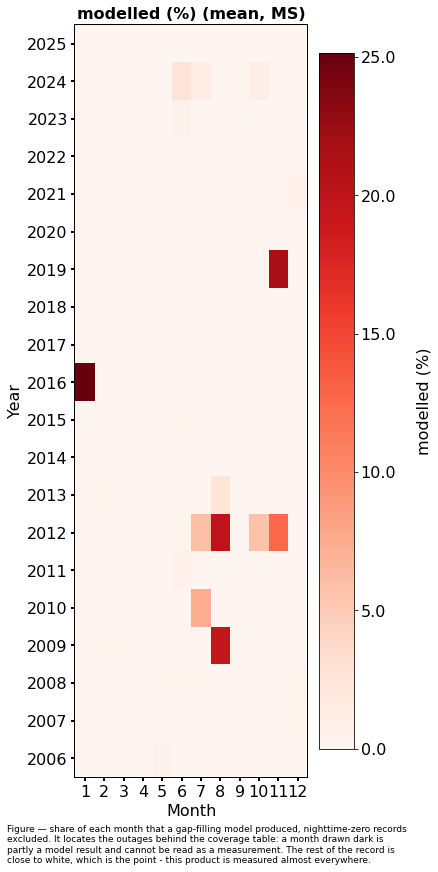

In [9]:
# Where the modelled records sit. Only codes 1 and 2 are drawn: the nighttime-zero code follows
# the seasons rather than the faults, and including it would put a band across every winter and
# hide the outages this figure exists to locate.
fig, ax = plt.subplots(figsize=(6, 12), dpi=72, layout="constrained")
_modelled_pct = (_ismodelled.astype(float) * 100).rename("modelled (%)")
dv.plotting.HeatmapYearMonth(series=_modelled_pct, agg='mean').plot(
    ax=ax, cmap="Reds", cb_digits_after_comma=1, zlabel="modelled (%)")
figcap(fig, f"share of each month that a gap-filling model produced, nighttime-zero records "
            f"excluded. It locates the outages behind the coverage table: a month drawn dark is "
            f"partly a model result and cannot be read as a measurement. The rest of the record "
            f"is close to white, which is the point - this product is measured almost everywhere.")


</br>


# Summary statistics


## Overall means


In [10]:
# Two summaries of the same record, because for radiation they answer different questions.
#
# The mean irradiance is what the sensor reported, averaged over every half-hour including the
# nights, so it is as much a statement about day length as about the sky. The annual total is the
# energy that actually arrived over the year and is the number a user of this product usually
# wants. Both are means of yearly values, so every year carries the same weight.
_yearly_avg = series.resample('YE').mean()
_yearly_total = series.resample('YE').apply(to_energy)

print(f"Mean irradiance (mean of yearly means): {_yearly_avg.mean():.2f} {units_plain} "
      f"+/- {_yearly_avg.std():.2f} SD between years")
print(f"Mean over all records:                  {series.mean():.2f} {units_plain}")
print()
print(f"Annual total (mean of yearly totals):   {_yearly_total.mean():.0f} MJ m-2 "
      f"+/- {_yearly_total.std():.0f} SD between years")
print(f"  the same in kWh m-2:                  {_yearly_total.mean() / 3.6:.0f} kWh m-2")
print(f"  range over {FIRST_YEAR}-{LAST_YEAR}:  {_yearly_total.min():.0f} to "
      f"{_yearly_total.max():.0f} MJ m-2 "
      f"({100 * (_yearly_total.max() / _yearly_total.min() - 1):.1f} % between the two)")


Mean irradiance (mean of yearly means): 146.03 W m-2 +/- 7.91 SD between years
Mean over all records:                  146.03 W m-2

Annual total (mean of yearly totals):   4608 MJ m-2 +/- 248 SD between years
  the same in kWh m-2:                  1280 kWh m-2
  range over 2006-2025:  4214 to 5082 MJ m-2 (20.6 % between the two)


## Year by year


In [11]:
# One table for the year-by-year view. Radiation gets its total as well as its mean, because the
# two rank years differently in a year with an unusual seasonal distribution, and the day-type
# counts detailed further below.
ym = per_year(series, 'mean')
yt = per_year(series, to_energy)
kt_year = per_year(daily['total_MJ'], 'sum') / per_year(daily['potential_MJ'], 'sum')

_daily_year = daily.groupby(daily.index.year)
yearly = pd.DataFrame({
    f"mean ({units_plain})": ym,
    "annual total (MJ m-2)": yt,
    "clearness index": kt_year,
    "measured peak (W m-2)": per_year(series_measured, 'max'),
    "brightest day (MJ m-2)": _daily_year['total_MJ'].max(),
    f"clear days (kt > {KT_CLEAR})": _daily_year['kt'].apply(lambda s: int((s > KT_CLEAR).sum())),
    f"overcast days (kt < {KT_OVERCAST})":
        _daily_year['kt'].apply(lambda s: int((s < KT_OVERCAST).sum())),
    "modelled (%)": coverage["modelled (%)"],
})
yearly["anomaly (MJ m-2)"] = yearly["annual total (MJ m-2)"] - yearly["annual total (MJ m-2)"].mean()
yearly["rank"] = yearly["annual total (MJ m-2)"].rank(ascending=False).astype(int)
yearly.index.name = "YEAR"

_fmt = {f"mean ({units_plain})": "{:.1f}", "annual total (MJ m-2)": "{:.0f}",
        "clearness index": "{:.3f}", "measured peak (W m-2)": "{:.0f}",
        "brightest day (MJ m-2)": "{:.1f}", "anomaly (MJ m-2)": "{:+.0f}",
        "modelled (%)": "{:.2f}", "rank": "{:.0f}",
        f"clear days (kt > {KT_CLEAR})": "{:.0f}",
        f"overcast days (kt < {KT_OVERCAST})": "{:.0f}"}
_styler = styled(yearly,
                 caption=f"{var} year by year: the mean irradiance, the energy that arrived, the "
                         f"clearness index of the whole year, the extremes it reached, the two "
                         f"day-type counts detailed below, and how much of it a model produced. "
                         f"Rank 1 is the brightest year",
                 fmt=_fmt, subset=["annual total (MJ m-2)"], cmap="YlOrRd")
display(anomaly_bars(_styler, "anomaly (MJ m-2)"))


Table — SW_IN year by year: the mean irradiance, the energy that arrived, the clearness index of the
whole year, the extremes it reached, the two day-type counts detailed below, and how much of it a
model produced. Rank 1 is the brightest year



,mean (W m-2),annual total (MJ m-2),clearness index,measured peak (W m-2),brightest day (MJ m-2),clear days (kt > 0.65),overcast days (kt < 0.25),modelled (%),anomaly (MJ m-2),rank
YEAR,,,,,,,,,,
2006,136.4,4302,0.456,1077,31.6,80,87,0.10,-306,18
2007,142.3,4488,0.476,1032,30.6,100,100,0.09,-121,15
2008,137.3,4343,0.460,1033,30.3,85,94,0.15,-266,17
2009,142.5,4493,0.476,1061,31.6,82,89,1.77,-115,14
2010,133.6,4214,0.447,1028,31.1,70,109,0.68,-394,20
2011,150.5,4747,0.503,1101,31.3,114,86,0.10,+139,7
2012,142.3,4500,0.477,1051,31.0,95,91,3.79,-108,13
2013,138.2,4358,0.462,1073,32.5,103,106,0.27,-251,16
2014,145.3,4582,0.486,1067,32.2,103,89,0.03,-26,11


## Period means


In [12]:
# Means of the yearly values, on the same basis as the overall means above. The record is split
# into the most recent N_RECENT_YEARS and everything before them, and the earlier period is the
# reference the recent one is compared against. The split follows the record, so it moves on as
# the dataset grows. Both boundary years are included.
_recent_from = LAST_YEAR - N_RECENT_YEARS + 1
_recent = slice(_recent_from, LAST_YEAR)
_earlier = slice(FIRST_YEAR, _recent_from - 1)

_rows = {}
for _label, _s in [(f"mean irradiance ({units_plain})", ym),
                   ("annual total (MJ m-2)", yt),
                   ("clearness index", kt_year)]:
    _a, _b = _s.loc[_earlier].mean(), _s.loc[_recent].mean()
    _rows[_label] = {f"{FIRST_YEAR}-{_recent_from - 1}": _a,
                     f"{_recent_from}-{LAST_YEAR}": _b,
                     "difference": _b - _a,
                     "difference (%)": 100 * (_b / _a - 1)}
periods = pd.DataFrame.from_dict(_rows, orient='index')

display(styled(periods,
               caption=f"the most recent {N_RECENT_YEARS} years against every year before them, on "
                       f"the three summaries above. The percentage column is the one to read: the "
                       f"three rows are in different units and a change in the clearness index is "
                       f"the part that is not explained by the sun",
               fmt={f"{FIRST_YEAR}-{_recent_from - 1}": "{:.3f}",
                    f"{_recent_from}-{LAST_YEAR}": "{:.3f}",
                    "difference": "{:+.3f}", "difference (%)": "{:+.2f}"},
               subset=["difference (%)"], cmap="RdBu_r", center=True))

print(f"The clearness index removes the sun from the comparison: it is the same denominator in "
      f"both periods, so a change in it is a change in the atmosphere or in the sensor. Notebook "
      f"01 and RADIATION_SENSOR_CONTINUITY together attribute about 3 % of the tower record's "
      f"level to the sensor from 2013, which is the same order as the difference above - read the "
      f"two together rather than either alone.")


Table — the most recent 10 years against every year before them, on the three summaries above. The
percentage column is the one to read: the three rows are in different units and a change in the
clearness index is the part that is not explained by the sun



,2006-2015,2016-2025,difference,difference (%)
mean irradiance (W m-2),142.479,149.591,+7.112,+4.99
annual total (MJ m-2),4495.626,4721.253,+225.627,+5.02
clearness index,0.477,0.500,+0.024,+5.01


The clearness index removes the sun from the comparison: it is the same denominator in both periods, so a change in it is a change in the atmosphere or in the sensor. Notebook 01 and RADIATION_SENSOR_CONTINUITY together attribute about 3 % of the tower record's level to the sensor from 2013, which is the same order as the difference above - read the two together rather than either alone.


## Brightest and dullest years


In [13]:
# The full ranking is the `rank` column of the yearly table above; this lists the two ends of it.
_by_total = yearly.sort_values("annual total (MJ m-2)", ascending=False)
_cols = ["annual total (MJ m-2)", f"mean ({units_plain})", "clearness index",
         f"clear days (kt > {KT_CLEAR})", f"overcast days (kt < {KT_OVERCAST})", "modelled (%)"]
display(styled(_by_total.head(N_RANKED)[_cols],
               caption=f"the {N_RANKED} brightest years by annual total",
               fmt={"annual total (MJ m-2)": "{:.0f}", f"mean ({units_plain})": "{:.1f}",
                    "clearness index": "{:.3f}", "modelled (%)": "{:.2f}",
                    f"clear days (kt > {KT_CLEAR})": "{:.0f}",
                    f"overcast days (kt < {KT_OVERCAST})": "{:.0f}"}, cmap="YlOrRd"))
display(styled(_by_total.tail(N_RANKED)[_cols].iloc[::-1],
               caption=f"the {N_RANKED} dullest years by annual total",
               fmt={"annual total (MJ m-2)": "{:.0f}", f"mean ({units_plain})": "{:.1f}",
                    "clearness index": "{:.3f}", "modelled (%)": "{:.2f}",
                    f"clear days (kt > {KT_CLEAR})": "{:.0f}",
                    f"overcast days (kt < {KT_OVERCAST})": "{:.0f}"}, cmap="Blues_r"))


Table — the 5 brightest years by annual total



,annual total (MJ m-2),mean (W m-2),clearness index,clear days (kt > 0.65),overcast days (kt < 0.25),modelled (%)
YEAR,,,,,,
2022,5082,161.1,0.539,130,63,0.00
2020,4941,156.3,0.523,135,86,0.00
2015,4928,156.3,0.522,137,76,0.09
2017,4852,153.9,0.514,109,86,0.00
2018,4817,152.7,0.511,107,86,0.01


Table — the 5 dullest years by annual total



,annual total (MJ m-2),mean (W m-2),clearness index,clear days (kt > 0.65),overcast days (kt < 0.25),modelled (%)
YEAR,,,,,,
2010,4214,133.6,0.447,70,109,0.68
2024,4226,133.6,0.448,75,96,0.42
2006,4302,136.4,0.456,80,87,0.10
2008,4343,137.3,0.460,85,94,0.15
2013,4358,138.2,0.462,103,106,0.27


</br>


# Seasonality


## Monthly totals per year


In [14]:
# Monthly totals rather than monthly means, for the reason given in About: a mean over a winter
# month averages in long nights. The colour scale runs over the whole table, so a month can be
# compared against every other month as well as against the same month in other years.
monthly_total = daily['total_MJ'].groupby(
    [daily.index.year, daily.index.month]).sum().unstack()
monthly_total.index.name = 'YEAR'
monthly_total.columns = [calendar.month_abbr[m] for m in monthly_total.columns]

monthly_avg = per_year_month(series, 'mean')
monthly_by_number = per_year_month(series, 'mean', month_names=False)

display(styled(monthly_total,
               caption=f"monthly {var} totals (MJ m-2), one row per year. The seasonal cycle "
                       f"dominates the table, which is the point: a July and a December of the "
                       f"same year differ by an order of magnitude, and a July compared against "
                       f"other Julys is the only comparison that means anything",
               fmt="{:.0f}", axis=None, cmap="YlOrRd"))


Table — monthly SW_IN totals (MJ m-2), one row per year. The seasonal cycle dominates the table,
which is the point: a July and a December of the same year differ by an order of magnitude, and a
July compared against other Julys is the only comparison that means anything



,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
YEAR,,,,,,,,,,,,
2006,138,144,287,423,507,697,763,394,405,269,167,109
2007,108,188,367,660,569,590,590,490,423,280,135,89
2008,130,269,316,361,648,592,655,546,362,243,141,80
2009,107,187,285,522,615,657,609,629,417,258,126,80
2010,100,164,339,554,433,579,688,474,435,245,126,78
2011,108,185,386,621,721,553,617,635,443,260,146,73
2012,94,246,468,380,654,605,619,619,388,218,119,90
2013,108,148,275,372,491,625,779,641,398,232,116,172
2014,122,199,439,492,584,765,524,518,423,275,159,82


## Climatology per calendar month


In [15]:
# The same monthly values read the other way round: what each calendar month looks like across the
# record, and which year holds its extremes. The peak is a half-hourly measured value, so it is far
# above any monthly mean.
_by_month = daily.groupby(daily.index.month)
_tot_by_month = monthly_total.copy()
_tot_by_month.columns = range(1, 13)

climatology = pd.DataFrame({
    "mean total (MJ m-2)": _tot_by_month.mean(),
    "lowest total (MJ m-2)": _tot_by_month.min(),
    "lowest in": _tot_by_month.idxmin(),
    "highest total (MJ m-2)": _tot_by_month.max(),
    "highest in": _tot_by_month.idxmax(),
    "mean clearness index": _by_month['kt'].mean(),
    f"mean ({units_plain})": monthly_by_number.mean(),
    "measured peak (W m-2)": series_measured.groupby(series_measured.index.month).max(),
})
climatology.index = [calendar.month_abbr[m] for m in climatology.index]
climatology.index.name = "MONTH"

display(styled(climatology,
               caption=f"each calendar month across {FIRST_YEAR}-{LAST_YEAR}: its mean total, the "
                       f"brightest and dullest occurrence of it and the year each fell in, its "
                       f"mean clearness index, and the highest half-hourly value ever measured in "
                       f"it. The clearness index is the column that is not dominated by the "
                       f"season, and it is flatter through the year than the totals are",
               fmt={"mean total (MJ m-2)": "{:.0f}", "lowest total (MJ m-2)": "{:.0f}",
                    "highest total (MJ m-2)": "{:.0f}", "lowest in": "{:.0f}",
                    "highest in": "{:.0f}", "mean clearness index": "{:.3f}",
                    f"mean ({units_plain})": "{:.1f}", "measured peak (W m-2)": "{:.0f}"},
               subset=["mean total (MJ m-2)"], cmap="YlOrRd"))


Table — each calendar month across 2006-2025: its mean total, the brightest and dullest occurrence
of it and the year each fell in, its mean clearness index, and the highest half-hourly value ever
measured in it. The clearness index is the column that is not dominated by the season, and it is
flatter through the year than the totals are



,mean total (MJ m-2),lowest total (MJ m-2),lowest in,highest total (MJ m-2),highest in,mean clearness index,mean (W m-2),measured peak (W m-2)
MONTH,,,,,,,,
Jan,118,92,2023,161,2022,0.349,43.9,592
Feb,199,144,2006,278,2019,0.426,81.6,750
Mar,368,275,2013,479,2022,0.482,137.3,912
Apr,507,361,2008,660,2007,0.515,195.6,1088
May,587,433,2010,721,2011,0.483,219.3,1111
Jun,656,547,2016,810,2023,0.521,253.1,1119
Jul,674,524,2014,790,2022,0.538,251.8,1067
Aug,579,394,2006,647,2016,0.532,216.1,1041
Sep,427,362,2008,511,2023,0.518,164.8,969


## Mean annual cycle


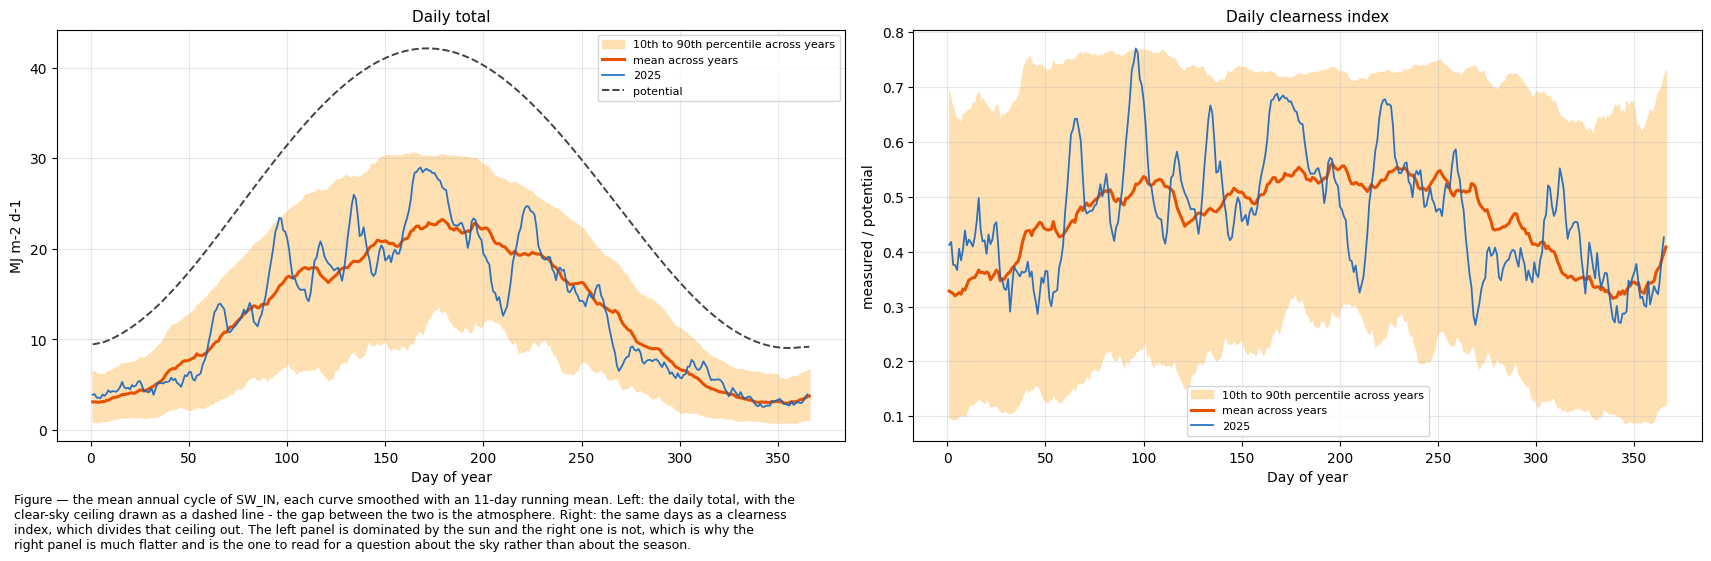

In [16]:
# Mean annual cycle of the daily total, with the spread across years behind it and the most recent
# year drawn on top. Bands are computed per day of year, so day 366 rests on the leap years only
# and is noisier than its neighbours. The clearness index is drawn beside it: it is the same days
# divided by what the sun could have delivered, which is what takes the astronomy out.
_doy = daily.copy()
_doy['doy'] = _doy.index.dayofyear
_g = _doy.groupby('doy')

fig, axs = plt.subplots(ncols=2, figsize=(17, 5.5), dpi=100, layout="constrained")

for _ax, _col, _title, _ylab in [
        (axs[0], 'total_MJ', 'Daily total', 'MJ m-2 d-1'),
        (axs[1], 'kt', 'Daily clearness index', 'measured / potential')]:
    _mean, _lo, _hi = _g[_col].mean(), _g[_col].quantile(0.1), _g[_col].quantile(0.9)
    _sm = lambda s: s.rolling(11, center=True, min_periods=3).mean()
    _ax.fill_between(_mean.index, _sm(_lo), _sm(_hi), color='#FFE0B2',
                     label="10th to 90th percentile across years")
    _ax.plot(_mean.index, _sm(_mean), color='#E65100', lw=2.2, label="mean across years")
    _last = _doy[_doy.index.year == LAST_YEAR].set_index('doy')[_col]
    _ax.plot(_last.index, _sm(_last), color='#1565C0', lw=1.3, alpha=0.9, label=str(LAST_YEAR))
    _ax.set_xlabel("Day of year")
    _ax.set_ylabel(_ylab)
    _ax.set_title(_title, fontsize=11)
    _ax.grid(alpha=0.3)
    _ax.legend(fontsize=8)
if 'potential_MJ' in _doy:
    axs[0].plot(_g['potential_MJ'].mean().index,
                _g['potential_MJ'].mean().rolling(11, center=True, min_periods=3).mean(),
                color='#424242', lw=1.4, ls='--', label="potential")
    axs[0].legend(fontsize=8)

figcap(fig, f"the mean annual cycle of {var}, each curve smoothed with an 11-day running mean. "
            f"Left: the daily total, with the clear-sky ceiling drawn as a dashed line - the gap "
            f"between the two is the atmosphere. Right: the same days as a clearness index, which "
            f"divides that ceiling out. The left panel is dominated by the sun and the right one "
            f"is not, which is why the right panel is much flatter and is the one to read for a "
            f"question about the sky rather than about the season.")


## Mean diurnal cycle per month


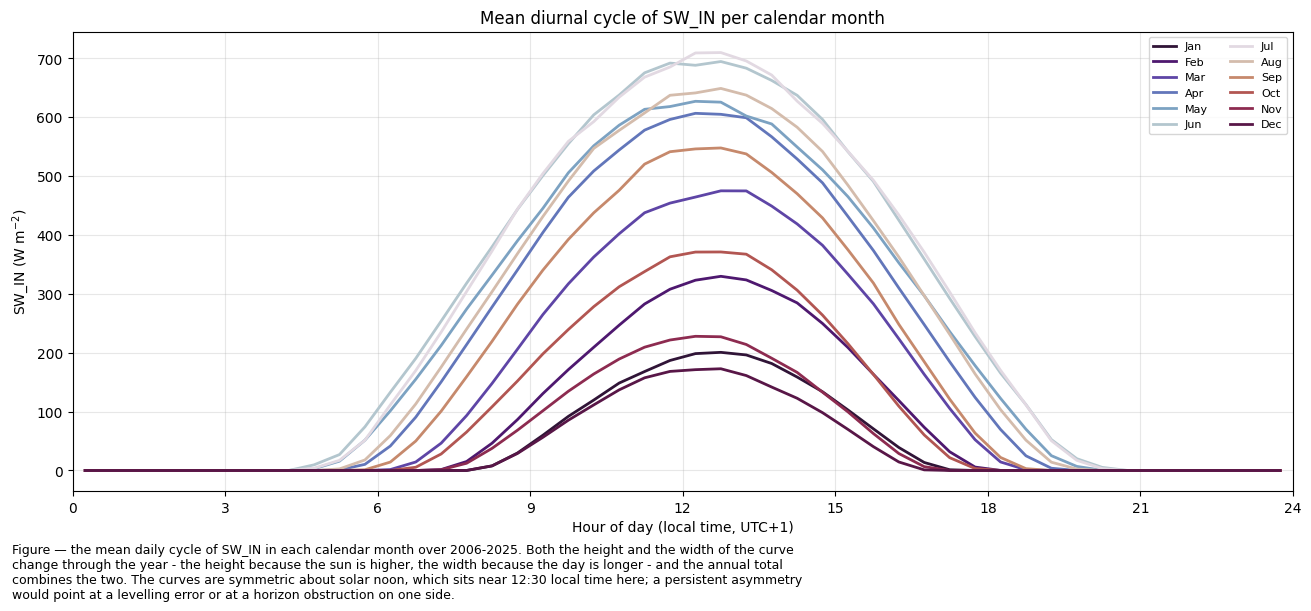

In [17]:
# Mean diurnal cycle per calendar month. The x axis is the centre of each 30MIN window, so the
# first point of the day is 00:15 and the last is 23:45.
_d = pd.DataFrame({'v': series})
_d['hour'] = _d.index.hour + _d.index.minute / 60
_d['month'] = _d.index.month
_diurnal = _d.pivot_table(index='hour', columns='month', values='v', aggfunc='mean')

fig, ax = plt.subplots(figsize=(13, 6), dpi=100, layout="constrained")
_cmap = plt.get_cmap('twilight_shifted')
for _m in _diurnal.columns:
    ax.plot(_diurnal.index, _diurnal[_m], color=_cmap((_m - 1) / 12), lw=2,
            label=calendar.month_abbr[_m])
ax.set_xlabel("Hour of day (local time, UTC+1)")
ax.set_ylabel(xlabel)
ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 3))
ax.set_title(f"Mean diurnal cycle of {var} per calendar month")
ax.grid(alpha=0.3)
ax.legend(fontsize=8, ncol=2)
figcap(fig, f"the mean daily cycle of {var} in each calendar month over {FIRST_YEAR}-{LAST_YEAR}. "
            f"Both the height and the width of the curve change through the year - the height "
            f"because the sun is higher, the width because the day is longer - and the annual "
            f"total combines the two. The curves are symmetric about solar noon, which sits near "
            f"12:30 local time here; a persistent asymmetry would point at a levelling error or "
            f"at a horizon obstruction on one side.")


## Month by hour


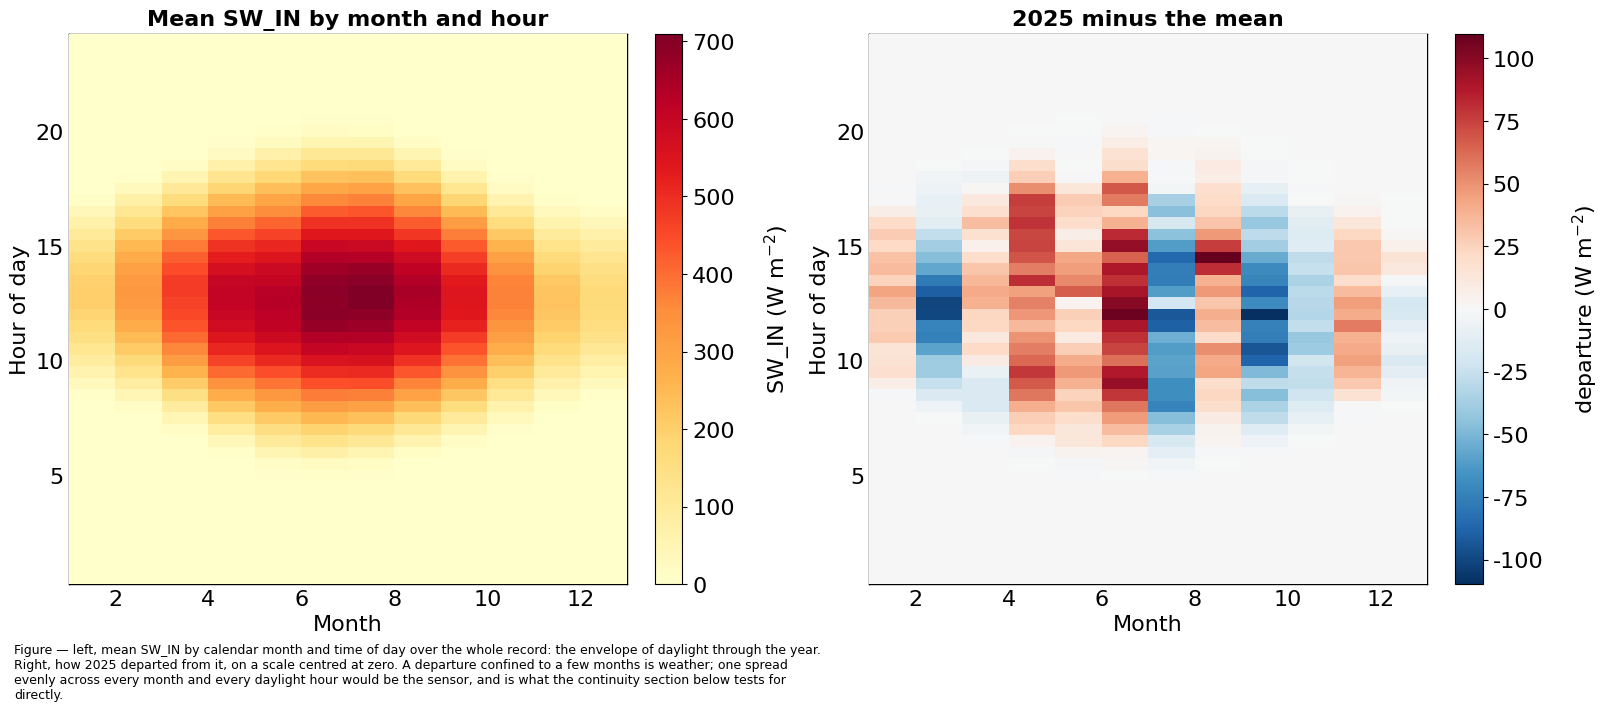

In [18]:
# The same cycle as a surface, next to the departure of the most recent year from it. The right
# panel is centred on zero, so above and below the long-term mean are equal distances from white.
_long = _diurnal.stack().rename("z").reset_index()
_long.columns = ['hour', 'month', 'z']

_last_d = _d[_d.index.year == LAST_YEAR].pivot_table(index='hour', columns='month', values='v',
                                                     aggfunc='mean')
_dep = (_last_d - _diurnal).stack().rename("z").reset_index()
_dep.columns = ['hour', 'month', 'z']
_absmax = _dep['z'].abs().max()

fig, axs = plt.subplots(ncols=2, figsize=(16, 7), dpi=100, layout="constrained")
dv.plotting.HeatmapXYZ(x=_long['month'], y=_long['hour'], z=_long['z']).plot(
    ax=axs[0], cmap='YlOrRd', cb_digits_after_comma=0, xlabel="Month", ylabel="Hour of day",
    zlabel=xlabel, format_style=dv.plotting.FormatStyle(title=f"Mean {var} by month and hour"))
dv.plotting.HeatmapXYZ(x=_dep['month'], y=_dep['hour'], z=_dep['z']).plot(
    ax=axs[1], cmap='RdBu_r', vmin=-_absmax, vmax=_absmax, cb_digits_after_comma=0,
    xlabel="Month", ylabel="Hour of day", zlabel=f"departure ({units})",
    format_style=dv.plotting.FormatStyle(title=f"{LAST_YEAR} minus the mean"))
figcap(fig, f"left, mean {var} by calendar month and time of day over the whole record: the "
            f"envelope of daylight through the year. Right, how {LAST_YEAR} departed from it, on "
            f"a scale centred at zero. A departure confined to a few months is weather; one "
            f"spread evenly across every month and every daylight hour would be the sensor, and "
            f"is what the continuity section below tests for directly.")


</br>


# Extremes and day types

Extremes come from the measured records only, for the reason given in About: a gap-filled value is
a model result and cannot set a record.


## Highest half-hourly value


In [19]:
# Extremes come from the measured records only (see About). The averaging window is reported
# instead of the timestamp, because the product is stored on TIMESTAMP_MIDDLE.
_peak_ts = series_measured.idxmax()
_peak = series_measured.max()
print(f"Highest measured half-hour: {_peak:.1f} {units_plain}")
print(f"  averaging window:         {window(_peak_ts)}")
print(f"  potential radiation then: {POTRAD.loc[_peak_ts]:.1f} {units_plain} "
      f"(clearness index {_peak / POTRAD.loc[_peak_ts]:.3f})")

# A gap-filled value outside the measured range would be quoted as a record by anyone reading the
# full series, so the two ranges are compared rather than left to be discovered.
_filled_max = series.where(df[flagname].isin([1, 2])).max()
print(f"\nHighest modelled half-hour: {_filled_max:.1f} {units_plain}")
if _filled_max > _peak:
    print("  (!) a modelled value exceeds every measurement - it would be read as a record")
else:
    print("  below the measured maximum, so no model result can be mistaken for a record")
assert _filled_max <= LIMITS[1], "a modelled value is outside the physical limits"


Highest measured half-hour: 1118.7 W m-2
  averaging window:         04 Jun 2021, 13:00 to 13:30
  potential radiation then: 1189.1 W m-2 (clearness index 0.941)

Highest modelled half-hour: 1014.0 W m-2
  below the measured maximum, so no model result can be mistaken for a record


## The brightest half-hours


In [20]:
# The extremes above in context. Neighbouring half-hours of the same afternoon fill this list,
# which is the point: a record half-hour is part of an episode, not an isolated reading.
_top = series_measured.nlargest(N_EXTREMES)
_table = pd.DataFrame({
    f"{var} ({units_plain})": _top.to_numpy(),
    "potential (W m-2)": POTRAD.loc[_top.index].to_numpy(),
    "clearness index": (_top / POTRAD.loc[_top.index]).to_numpy(),
    "averaging window": [window(t) for t in _top.index],
})
_table.index = range(1, len(_table) + 1)
_table.index.name = "rank"
display(styled(_table,
               caption=f"the {N_EXTREMES} highest measured half-hours of the record. A clearness "
                       f"index above 1 is cloud enhancement: a bright cloud edge reflecting extra "
                       f"light onto the sensor while the sun is not obscured, which is why the "
                       f"highest half-hours of the record are not the clearest ones",
               fmt={f"{var} ({units_plain})": "{:.1f}", "potential (W m-2)": "{:.1f}",
                    "clearness index": "{:.3f}"},
               subset=[f"{var} ({units_plain})"], cmap="YlOrRd"))


Table — the 10 highest measured half-hours of the record. A clearness index above 1 is cloud
enhancement: a bright cloud edge reflecting extra light onto the sensor while the sun is not
obscured, which is why the highest half-hours of the record are not the clearest ones



,SW_IN (W m-2),potential (W m-2),clearness index,averaging window
rank,,,,
1,1118.7,1189.1,0.941,"04 Jun 2021, 13:00 to 13:30"
2,1111.0,1147.4,0.968,"03 May 2017, 12:00 to 12:30"
3,1100.6,1201.3,0.916,"28 May 2011, 12:00 to 12:30"
4,1100.2,1197.7,0.919,"18 Jun 2016, 13:00 to 13:30"
5,1092.1,1212.3,0.901,"10 Jun 2011, 12:00 to 12:30"
6,1088.1,1128.0,0.965,"28 Apr 2019, 12:30 to 13:00"
7,1087.8,1176.6,0.925,"25 May 2022, 13:00 to 13:30"
8,1086.8,1161.5,0.936,"17 May 2025, 13:00 to 13:30"
9,1084.9,1189.0,0.912,"20 May 2011, 12:00 to 12:30"


## The brightest and dullest days


In [21]:
# The same for daily totals. A daily total is computed over all records of the day, gap-filled ones
# included, so the modelled share is listed next to it.
_measured_days = daily[daily['filled_share'] == 0]

for _label, _sel, _cmap in [("brightest", _measured_days.nlargest(N_EXTREMES, 'total_MJ'), "YlOrRd"),
                            ("dullest", _measured_days.nsmallest(N_EXTREMES, 'total_MJ'), "Blues_r")]:
    _t = pd.DataFrame({
        "date": [f"{d:%d %b %Y}" for d in _sel.index],
        "total (MJ m-2)": _sel['total_MJ'].to_numpy(),
        "potential (MJ m-2)": _sel['potential_MJ'].to_numpy(),
        "clearness index": _sel['kt'].to_numpy(),
        "peak (W m-2)": _sel['peak'].to_numpy(),
    })
    _t.index = range(1, len(_t) + 1)
    _t.index.name = "rank"
    display(styled(_t,
                   caption=f"the {N_EXTREMES} {_label} days of the record, entirely measured days "
                           f"only. Read the clearness index beside the total: the brightest days "
                           f"are all near midsummer and owe most of their total to the sun, while "
                           f"the dullest are near midwinter and would be dull in any season",
                   fmt={"total (MJ m-2)": "{:.2f}", "potential (MJ m-2)": "{:.2f}",
                        "clearness index": "{:.3f}", "peak (W m-2)": "{:.0f}"},
                   subset=["total (MJ m-2)"], cmap=_cmap))


Table — the 10 brightest days of the record, entirely measured days only. Read the clearness index
beside the total: the brightest days are all near midsummer and owe most of their total to the sun,
while the dullest are near midwinter and would be dull in any season



,date,total (MJ m-2),potential (MJ m-2),clearness index,peak (W m-2)
rank,,,,,
1,14 Jun 2021,32.54,42.06,0.774,993
2,06 Jun 2013,32.49,41.67,0.780,1005
3,31 May 2021,32.29,41.18,0.784,991
4,30 May 2021,32.29,41.09,0.786,995
5,24 Jun 2015,32.20,42.13,0.764,1001
6,18 Jun 2017,32.19,42.15,0.764,995
7,21 Jun 2014,32.18,42.16,0.763,979
8,02 Jul 2022,32.08,41.85,0.767,982
9,29 Jun 2019,31.98,41.99,0.762,986


Table — the 10 dullest days of the record, entirely measured days only. Read the clearness index
beside the total: the brightest days are all near midsummer and owe most of their total to the sun,
while the dullest are near midwinter and would be dull in any season



,date,total (MJ m-2),potential (MJ m-2),clearness index,peak (W m-2)
rank,,,,,
1,21 Nov 2008,0.26,11.19,0.024,18
2,24 Dec 2025,0.27,9.04,0.030,18
3,05 Jan 2012,0.27,9.55,0.029,19
4,28 Nov 2012,0.29,10.30,0.028,18
5,18 Dec 2014,0.32,9.05,0.036,20
6,04 Jan 2018,0.33,9.48,0.035,22
7,23 Nov 2013,0.35,11.05,0.032,33
8,23 Dec 2022,0.35,9.03,0.039,24
9,20 Nov 2015,0.36,11.49,0.032,24


## Day types

A "sunny day" counted on the daily total is largely a statement about the season — a clear December
day carries less energy than an overcast June one. Counted on the clearness index it is a statement
about the sky, and only then are two years comparable.


Table — day types per year. The first two rows count the state of the sky and are comparable between
years; the next two count energy and mix the sky with the season. The spell columns say whether a
year reached its count in one run or in many - a year can hold a high clear-day count without ever
holding a week of them, and the two say different things about the season



,clear (kt > 0.65),overcast (kt < 0.25),days > 20 MJ m-2,days < 2 MJ m-2,longest clear spell (d),longest overcast spell (d)
YEAR,,,,,,
2006,80,87,70,29,9,5
2007,100,100,87,45,9,6
2008,85,94,75,36,8,6
2009,82,89,95,40,6,8
2010,70,109,76,36,6,5
2011,114,86,103,40,8,10
2012,95,91,85,45,5,7
2013,103,106,89,34,11,6
2014,103,89,90,38,9,12


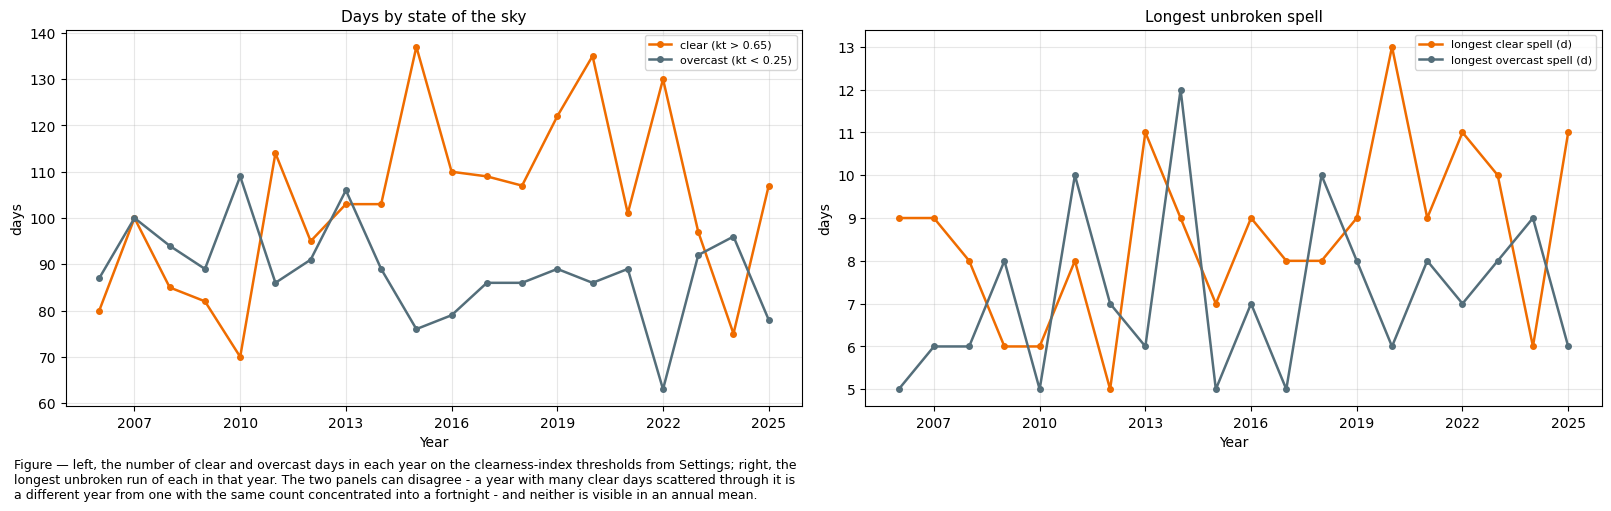

In [22]:
# Day-type counts per year on the clearness index, which is the only way to count a "sunny day"
# without the answer being a statement about the season. Thresholds are in the Settings cell and
# are stated in the column names, because the counts mean nothing without them.
_dg = daily.groupby(daily.index.year)
daytypes = pd.DataFrame({
    f"clear (kt > {KT_CLEAR})": _dg['kt'].apply(lambda s: int((s > KT_CLEAR).sum())),
    f"overcast (kt < {KT_OVERCAST})": _dg['kt'].apply(lambda s: int((s < KT_OVERCAST).sum())),
    "days > 20 MJ m-2": _dg['total_MJ'].apply(lambda s: int((s > 20).sum())),
    "days < 2 MJ m-2": _dg['total_MJ'].apply(lambda s: int((s < 2).sum())),
    "longest clear spell (d)": _dg.apply(lambda g: longest_spell(g['kt'] > KT_CLEAR)[0]),
    "longest overcast spell (d)": _dg.apply(lambda g: longest_spell(g['kt'] < KT_OVERCAST)[0]),
})
daytypes.index.name = "YEAR"
display(styled(daytypes,
               caption=f"day types per year. The first two rows count the state of the sky and are "
                       f"comparable between years; the next two count energy and mix the sky with "
                       f"the season. The spell columns say whether a year reached its count in one "
                       f"run or in many - a year can hold a high clear-day count without ever "
                       f"holding a week of them, and the two say different things about the season",
               fmt="{:.0f}", cmap="YlOrRd"))

fig, axs = plt.subplots(ncols=2, figsize=(16, 5), dpi=100, layout="constrained", sharex=True)
for _ax, _cols, _title, _colours in [
        (axs[0], [f"clear (kt > {KT_CLEAR})", f"overcast (kt < {KT_OVERCAST})"],
         "Days by state of the sky", ['#EF6C00', '#546E7A']),
        (axs[1], ["longest clear spell (d)", "longest overcast spell (d)"],
         "Longest unbroken spell", ['#EF6C00', '#546E7A'])]:
    for _c, _col in zip(_cols, _colours):
        _ax.plot(daytypes.index, daytypes[_c], marker='o', ms=4, lw=1.8, color=_col, label=_c)
    _ax.set_xlabel("Year")
    _ax.set_ylabel("days")
    _ax.set_title(_title, fontsize=11)
    _ax.grid(alpha=0.3)
    _ax.legend(fontsize=8)
    year_axis(_ax)
figcap(fig, f"left, the number of clear and overcast days in each year on the clearness-index "
            f"thresholds from Settings; right, the longest unbroken run of each in that year. The "
            f"two panels can disagree - a year with many clear days scattered through it is a "
            f"different year from one with the same count concentrated into a fortnight - and "
            f"neither is visible in an annual mean.")


</br>


# Distributions

Of the **daylight** half-hours only. Over all records the distribution is 48 % a spike at zero,
which is a statement about the length of the night and swamps everything else.


## Ridgelines per year


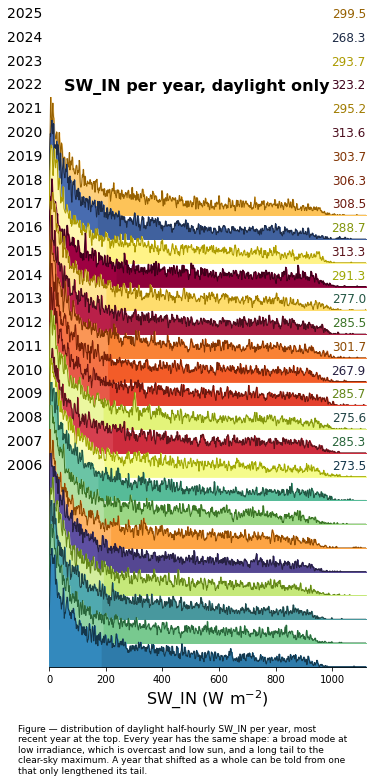

In [23]:
# Distributions of the DAYLIGHT half-hours only. Over all records the distribution is 48 % a spike
# at zero, which is a statement about the length of the night and swamps everything else; the
# nights are described by the coverage and the diurnal sections instead.
rp = dv.plotting.RidgeLinePlot(series=daylight.dropna())
rp.plot(
    how='yearly',
    kd_kwargs=None,
    xlim=xlim,
    ylim=[0, 0.006],
    hspace=-0.8,
    fig_width=5,
    fig_height=9,
    shade_percentile=0.5,
    show_mean_line=False,
    format_style=dv.plotting.FormatStyle(xlabel=xlabel, title=f"{var} per year, daylight only"),
    fig_dpi=72,
    showplot=True,
    ascending=False
)
figcap(rp.fig, f"distribution of daylight half-hourly {var} per year, most recent year at the top. "
               f"Every year has the same shape: a broad mode at low irradiance, which is overcast "
               f"and low sun, and a long tail to the clear-sky maximum. A year that shifted as a "
               f"whole can be told from one that only lengthened its tail.")


## Ridgelines per month


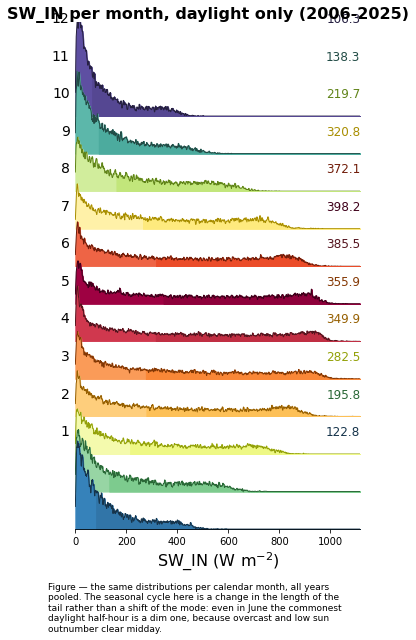

In [24]:
rp.plot(
    how='monthly',
    kd_kwargs=None,
    xlim=xlim,
    ylim=[0, 0.010],
    hspace=-0.6,
    fig_width=4.5,
    fig_height=8,
    shade_percentile=0.5,
    show_mean_line=False,
    format_style=dv.plotting.FormatStyle(
        xlabel=xlabel, title=f"{var} per month, daylight only ({FIRST_YEAR}-{LAST_YEAR})"),
    fig_dpi=72,
    showplot=True,
    ascending=False
)
figcap(rp.fig, f"the same distributions per calendar month, all years pooled. The seasonal cycle "
               f"here is a change in the length of the tail rather than a shift of the mode: even "
               f"in June the commonest daylight half-hour is a dim one, because overcast and low "
               f"sun outnumber clear midday.")


## Percentiles per year


Table — percentiles of daylight half-hourly SW_IN per year, the numbers behind the bands: whether a
year moved as a whole or only at one edge



,5th percentile (W m-2),25th percentile (W m-2),50th percentile (W m-2),75th percentile (W m-2),95th percentile (W m-2)
YEAR,,,,,
2006,10.2,61.5,185.8,432.4,811.9
2007,9.4,57.1,192.5,475.0,819.2
2008,9.7,59.5,187.2,440.8,811.4
2009,10.6,58.1,193.5,463.1,815.7
2010,8.8,54.7,170.3,429.3,800.5
2011,9.9,67.9,218.7,497.4,824.4
2012,8.7,55.7,193.3,473.0,812.4
2013,9.6,56.5,173.6,431.1,856.1
2014,10.5,59.3,195.2,478.3,843.3


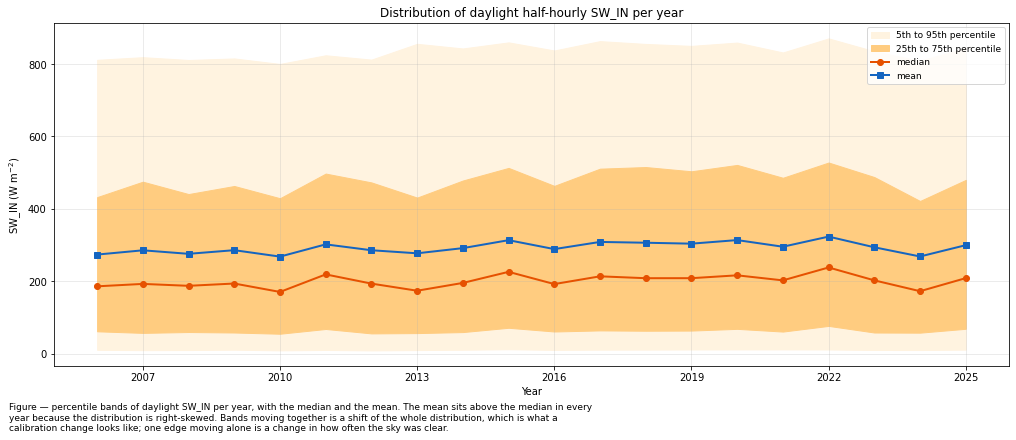

In [25]:
# Quantiles of the daylight half-hourly values per year. The ridgelines above show the shape of
# each year's distribution; this shows where its edges moved. A shift of the median with unchanged
# 5th and 95th percentiles is a different signal from a tail that lengthens alone.
QUANTILES = [0.05, 0.25, 0.5, 0.75, 0.95]
_dl = daylight.dropna()
quantiles = _dl.groupby(_dl.index.year).quantile(QUANTILES).unstack()
quantiles.index.name = "YEAR"

fig, ax = plt.subplots(figsize=(14, 6), dpi=72, layout="constrained")
ax.fill_between(quantiles.index, quantiles[0.05], quantiles[0.95], color='#FFF3E0',
                label="5th to 95th percentile")
ax.fill_between(quantiles.index, quantiles[0.25], quantiles[0.75], color='#FFCC80',
                label="25th to 75th percentile")
ax.plot(quantiles.index, quantiles[0.5], color='#E65100', lw=2, marker='o', label="median")
ax.plot(quantiles.index, _dl.groupby(_dl.index.year).mean(), color='#1565C0', lw=2, marker='s',
        label="mean")
ax.set_xlabel("Year")
ax.set_ylabel(xlabel)
ax.set_title(f"Distribution of daylight half-hourly {var} per year")
ax.grid(alpha=0.3)
year_axis(ax)
ax.legend(fontsize=9)
figcap(fig, f"percentile bands of daylight {var} per year, with the median and the mean. The mean "
            f"sits above the median in every year because the distribution is right-skewed. Bands "
            f"moving together is a shift of the whole distribution, which is what a calibration "
            f"change looks like; one edge moving alone is a change in how often the sky was clear.")
fig.show()

_table = quantiles.copy()
_table.columns = [f"{int(q * 100)}th percentile ({units_plain})" for q in _table.columns]
display(styled(_table,
               caption=f"percentiles of daylight half-hourly {var} per year, the numbers behind the "
                       f"bands: whether a year moved as a whole or only at one edge",
               fmt="{:.1f}", axis=None, cmap="YlOrRd"))


</br>


# Heatmap plots


## Half-hourly


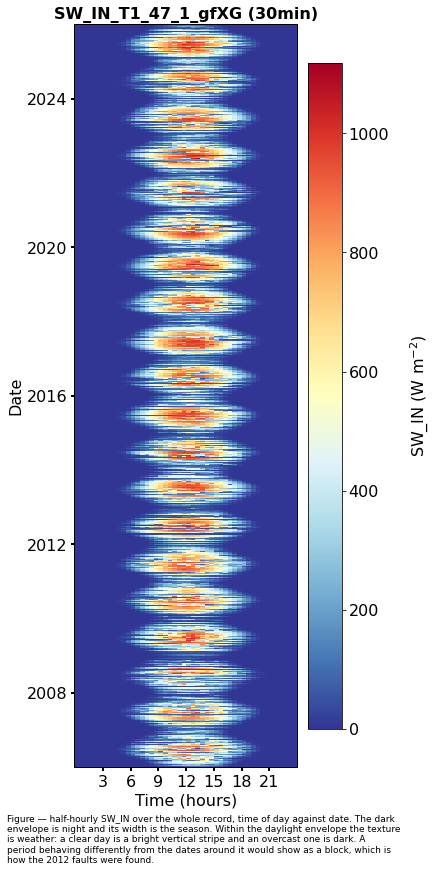

In [26]:
fig, axs = plt.subplots(ncols=1, figsize=(6, 12), dpi=72, layout="constrained")
dv.plotting.HeatmapDateTime(series=series).plot(ax=axs, cb_digits_after_comma=0, zlabel=xlabel)
figcap(fig, f"half-hourly {var} over the whole record, time of day against date. The dark envelope "
            f"is night and its width is the season. Within the daylight envelope the texture is "
            f"weather: a clear day is a bright vertical stripe and an overcast one is dark. A "
            f"period behaving differently from the dates around it would show as a block, which "
            f"is how the 2012 faults were found.")


## Monthly


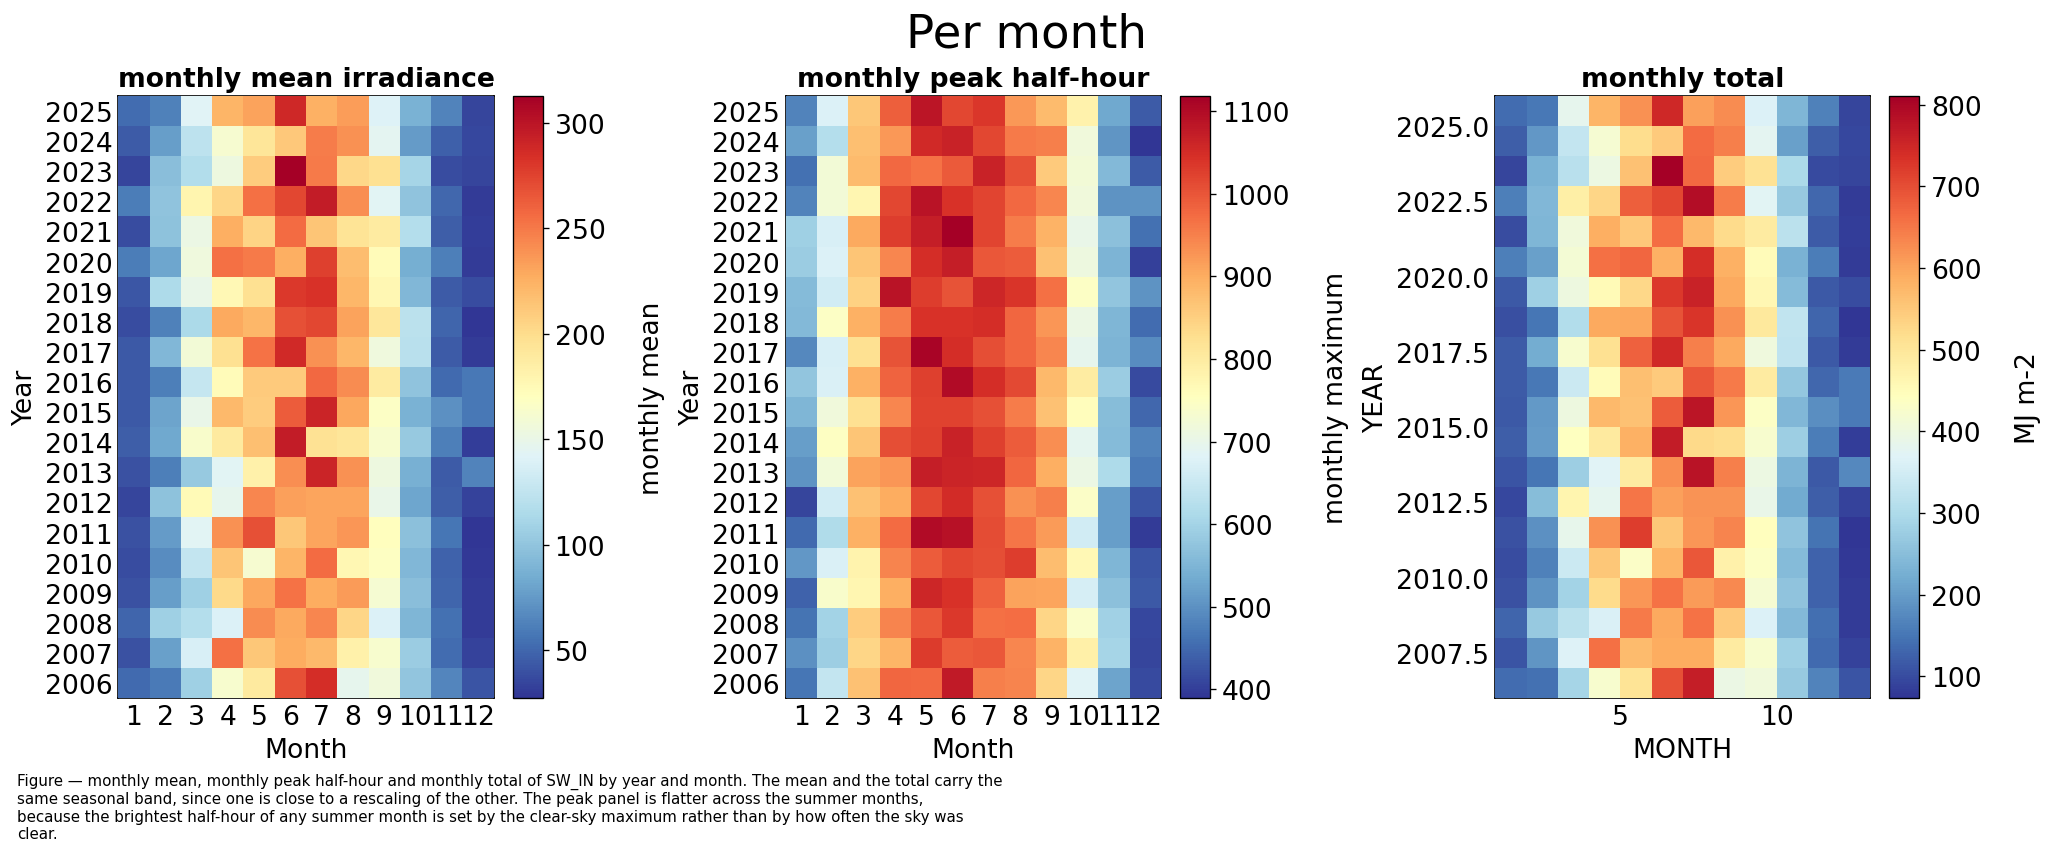

In [27]:
fig, axs = plt.subplots(ncols=3, figsize=(17, 7), dpi=120, layout="constrained")
fig.suptitle('Per month', fontsize=28)

# HeatmapYearMonth aggregates the half-hourly series itself, so it is passed unresampled.
dv.plotting.HeatmapYearMonth(series=series, agg='mean').plot(
    ax=axs[0], cb_digits_after_comma=0, zlabel="monthly mean",
    format_style=dv.plotting.FormatStyle(title="monthly mean irradiance"))
dv.plotting.HeatmapYearMonth(series=series, agg='max').plot(
    ax=axs[1], cb_digits_after_comma=0, zlabel="monthly maximum",
    format_style=dv.plotting.FormatStyle(title="monthly peak half-hour"))

# The monthly total is not one of the available aggregations, so it is built from the daily totals
# and drawn on the same grid with HeatmapXYZ.
_tot_lf = monthly_total.copy()
_tot_lf.columns = range(1, 13)
_tot_lf = _tot_lf.stack().rename("monthly total").reset_index()
_tot_lf.columns = ['YEAR', 'MONTH', 'monthly total']
dv.plotting.HeatmapXYZ(x=_tot_lf['MONTH'], y=_tot_lf['YEAR'], z=_tot_lf['monthly total']).plot(
    ax=axs[2], cb_digits_after_comma=0, zlabel="MJ m-2",
    format_style=dv.plotting.FormatStyle(title="monthly total"))
figcap(fig, f"monthly mean, monthly peak half-hour and monthly total of {var} by year and month. "
            f"The mean and the total carry the same seasonal band, since one is close to a "
            f"rescaling of the other. The peak panel is flatter across the summer months, because "
            f"the brightest half-hour of any summer month is set by the clear-sky maximum rather "
            f"than by how often the sky was clear.")


## Monthly ranks


Table — the ranks behind the grid above, 1 being the brightest occurrence of that calendar month



,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
YEAR,,,,,,,,,,,,
2006,4,20,18,15,18,7,4,20,13,7,2,4
2007,13,12,11,1,11,15,18,18,10,5,8,10
2008,5,2,15,20,6,14,12,14,20,14,7,16
2009,15,13,19,10,8,11,16,6,12,11,12,17
2010,18,15,13,8,20,17,9,19,8,13,13,18
2011,14,14,9,3,1,18,15,5,7,10,6,20
2012,19,3,2,18,5,13,14,9,16,19,15,9
2013,12,19,20,19,19,12,2,3,15,17,17,1
2014,6,9,3,12,10,2,20,17,11,6,4,12


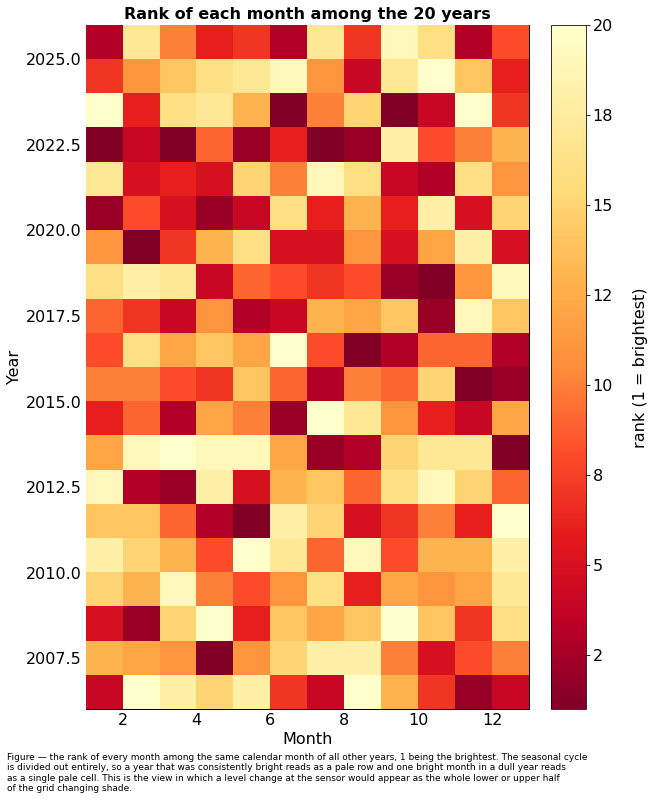

In [28]:
# Monthly ranks: for each calendar month, where every year sits among the others. It removes the
# seasonal cycle entirely, which the totals panel above cannot.
_ranks = monthly_total.rank(ascending=False, axis=0)
_ranks_lf = _ranks.copy()
_ranks_lf.columns = range(1, 13)
_ranks_lf = _ranks_lf.stack().rename("rank").reset_index()
_ranks_lf.columns = ['YEAR', 'MONTH', 'rank']

fig, ax = plt.subplots(figsize=(9, 11), dpi=72, layout="constrained")
dv.plotting.HeatmapXYZ(x=_ranks_lf['MONTH'], y=_ranks_lf['YEAR'], z=_ranks_lf['rank']).plot(
    ax=ax, cmap='YlOrRd_r', cb_digits_after_comma=0, xlabel="Month", ylabel="Year",
    zlabel="rank (1 = brightest)",
    format_style=dv.plotting.FormatStyle(title=f"Rank of each month among the {len(monthly_total)} years"))
figcap(fig, f"the rank of every month among the same calendar month of all other years, 1 being "
            f"the brightest. The seasonal cycle is divided out entirely, so a year that was "
            f"consistently bright reads as a pale row and one bright month in a dull year reads "
            f"as a single pale cell. This is the view in which a level change at the sensor would "
            f"appear as the whole lower or upper half of the grid changing shade.")

display(styled(_ranks, caption=f"the ranks behind the grid above, 1 being the brightest occurrence "
                               f"of that calendar month", fmt="{:.0f}", axis=None, cmap="YlOrRd_r"))


</br>


# Anomalies and trends


## Per year


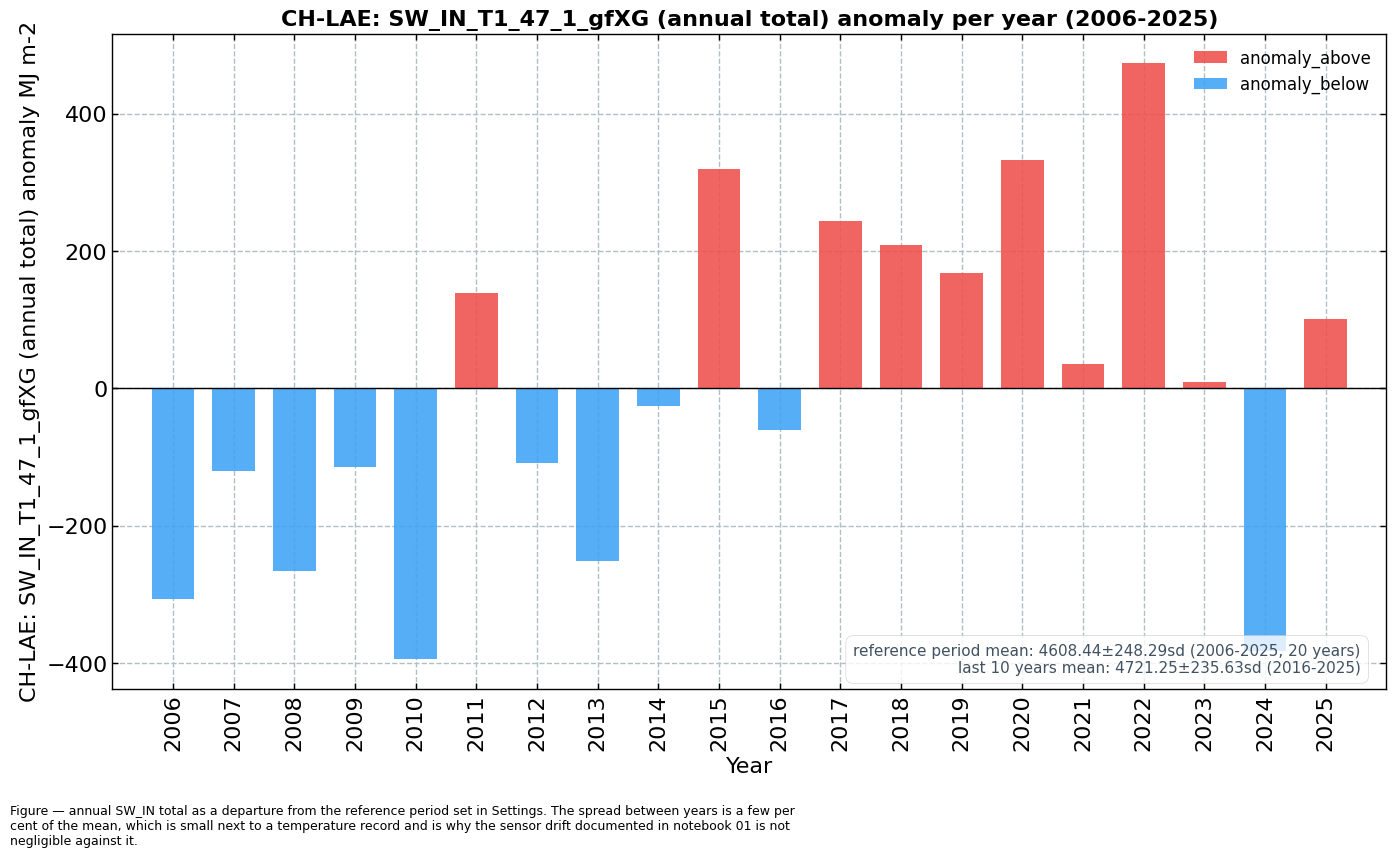

In [29]:
# Reference period from the Settings cell. It spans the whole record here, so the anomalies are
# departures from the record's own mean rather than from a climate normal.
#
# The anomaly is taken on the ANNUAL TOTAL rather than on the mean irradiance. The two are nearly
# proportional, but the total is the quantity a reader of this product cares about and its units
# say what it is.
series_label = f"CH-LAE: {varname}"
_anomalies_year = LongtermAnomaliesYear(series=yt.rename(varname),
                                        series_label=f"{series_label} (annual total)",
                                        series_units="MJ m-2",
                                        reference_start_year=REFERENCE_START_YEAR,
                                        reference_end_year=REFERENCE_END_YEAR)
_anomalies_year.plot()
figcap(_anomalies_year.fig,
       f"annual {var} total as a departure from the reference period set in Settings. The spread "
       f"between years is a few per cent of the mean, which is small next to a temperature record "
       f"and is why the sensor drift documented in notebook 01 is not negligible against it.")


## Per calendar month


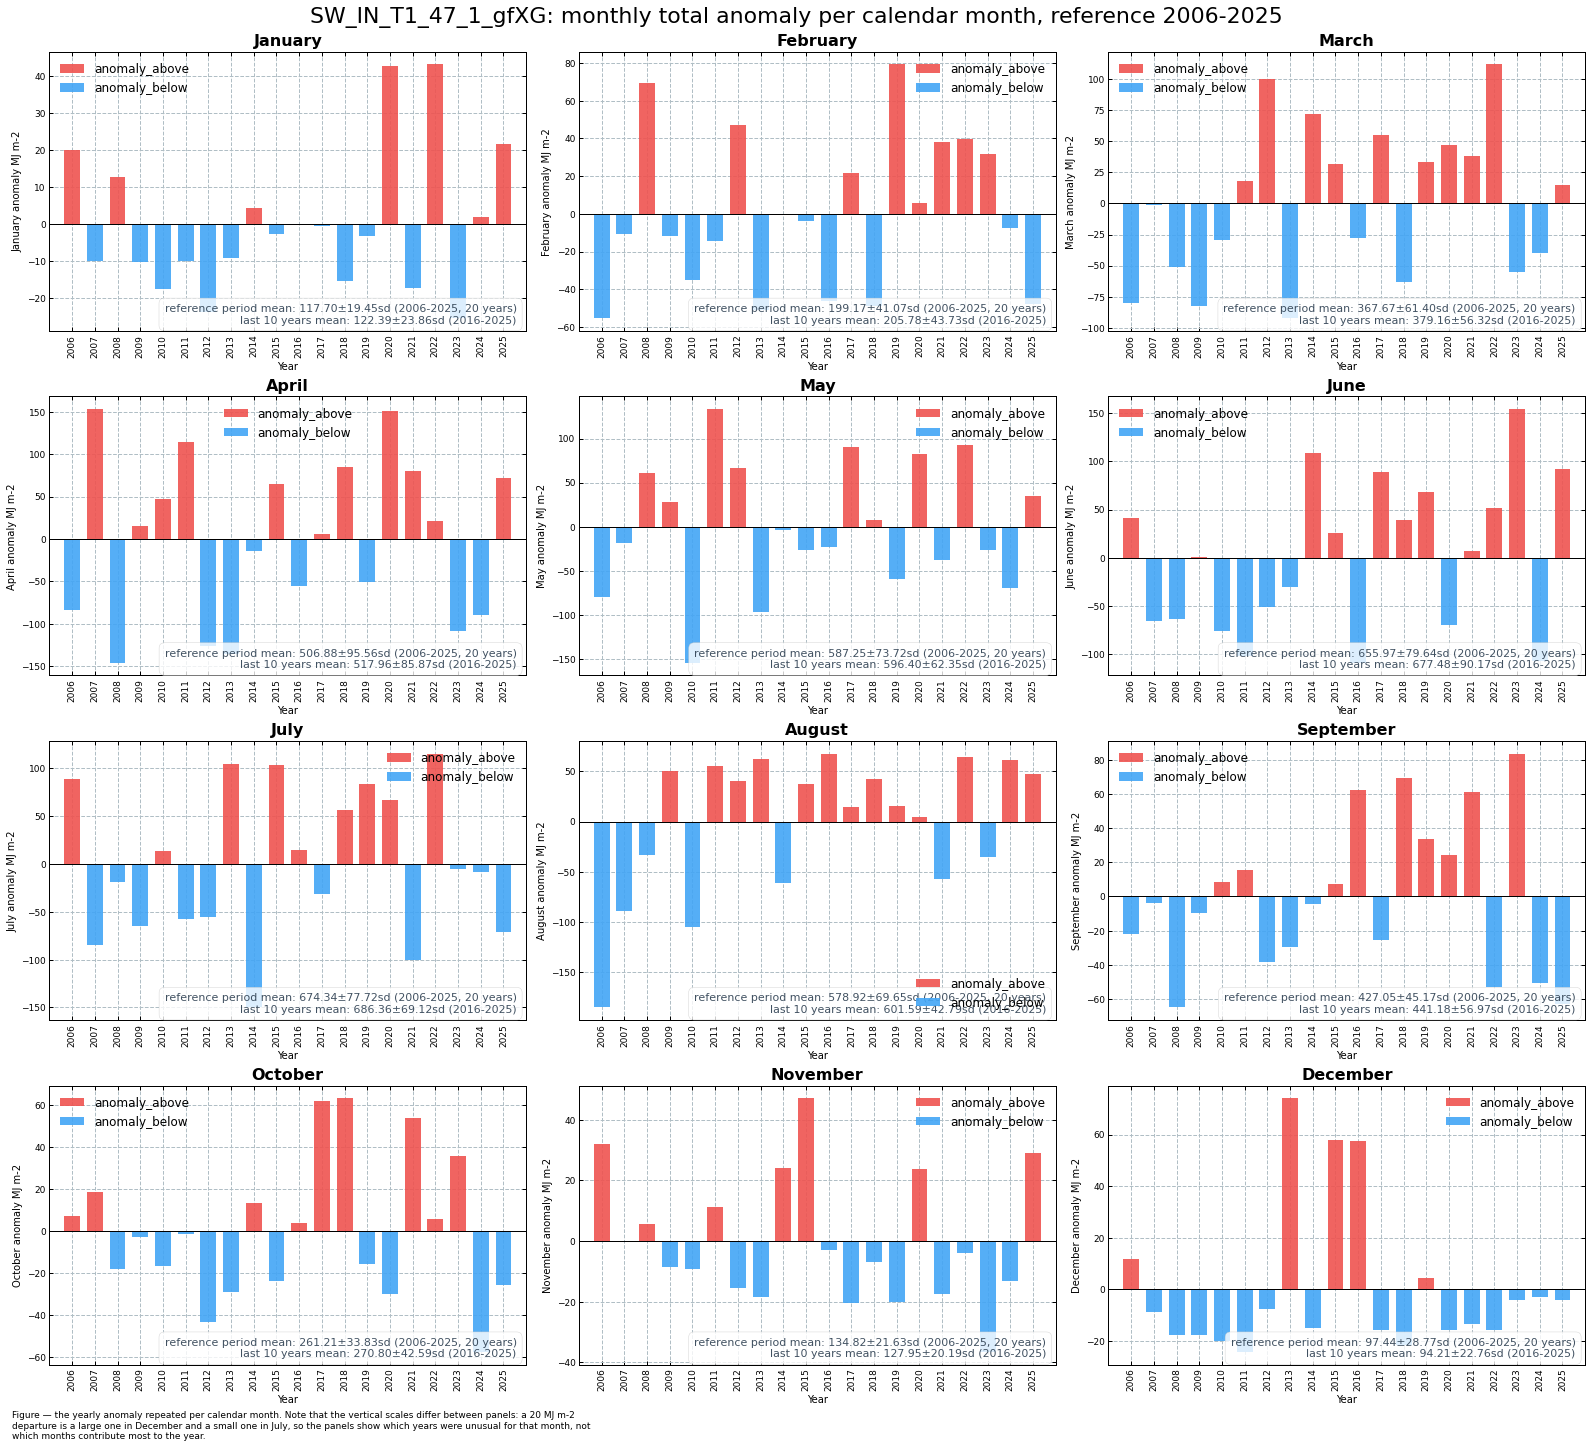

In [30]:
# The same calculation per calendar month, each against the mean of that month over the reference
# period. A single month can run against the year it sits in, which the yearly plot cannot show.
monthly_total_by_number = monthly_total.copy()
monthly_total_by_number.columns = range(1, 13)

fig, axs = plt.subplots(nrows=4, ncols=3, figsize=(22, 20), dpi=72, layout="constrained")
fig.suptitle(f"{varname}: monthly total anomaly per calendar month, reference "
             f"{REFERENCE_START_YEAR}-{REFERENCE_END_YEAR}", fontsize=22)
for _month, _ax in zip(monthly_total_by_number.columns, axs.flatten()):
    LongtermAnomaliesYear(series=monthly_total_by_number[_month].rename(varname),
                          series_label=calendar.month_name[_month],
                          series_units="MJ m-2",
                          reference_start_year=REFERENCE_START_YEAR,
                          reference_end_year=REFERENCE_END_YEAR).plot(
        ax=_ax, format_style=dv.plotting.FormatStyle(title=calendar.month_name[_month],
                                                     axlabel_fontsize=10, ticks_fontsize=9))
figcap(fig, f"the yearly anomaly repeated per calendar month. Note that the vertical scales differ "
            f"between panels: a 20 MJ m-2 departure is a large one in December and a small one in "
            f"July, so the panels show which years were unusual for that month, not which months "
            f"contribute most to the year.")


## Anomaly by year and month


Table — monthly SW_IN total anomaly (%) against 2006-2025, the numbers behind the grid



,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
YEAR,,,,,,,,,,,,
2006,+16.9,-27.8,-21.9,-16.5,-13.7,+6.2,+13.1,-32.0,-5.1,+2.8,+23.8,+12.1
2007,-8.5,-5.4,-0.3,+30.2,-3.1,-10.0,-12.5,-15.3,-0.9,+7.1,-0.1,-9.0
2008,+10.7,+34.9,-14.0,-28.8,+10.4,-9.8,-2.8,-5.7,-15.2,-7.0,+4.2,-18.3
2009,-8.8,-6.0,-22.4,+3.0,+4.7,+0.1,-9.6,+8.7,-2.2,-1.1,-6.3,-18.3
2010,-14.9,-17.6,-7.9,+9.3,-26.3,-11.7,+2.0,-18.1,+1.9,-6.3,-6.8,-20.4
2011,-8.5,-7.3,+5.0,+22.6,+22.7,-15.7,-8.5,+9.7,+3.7,-0.5,+8.4,-24.9
2012,-20.2,+23.5,+27.2,-24.9,+11.4,-7.8,-8.2,+7.0,-9.1,-16.7,-11.5,-7.9
2013,-7.9,-25.5,-25.1,-26.7,-16.4,-4.7,+15.6,+10.7,-6.9,-11.1,-13.8,+76.0
2014,+3.7,-0.3,+19.5,-2.8,-0.6,+16.6,-22.2,-10.5,-1.0,+5.2,+18.0,-15.4


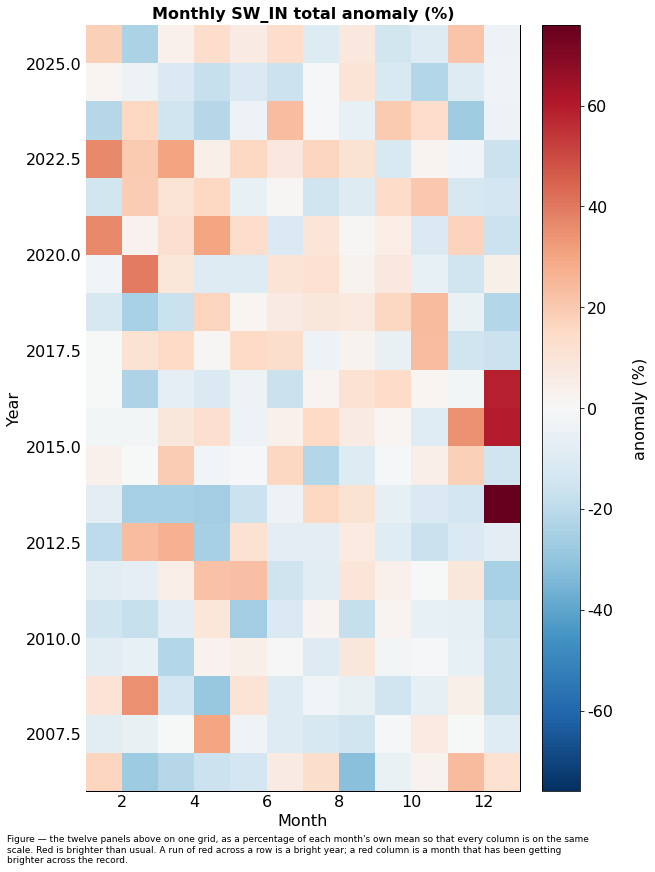

In [31]:
# All twelve panels above on one grid, plus the table behind them. The anomalies are expressed as
# a PERCENTAGE of each month's own mean, because an absolute grid would be a picture of the
# seasonal cycle: a 15 MJ m-2 departure is routine in June and impossible in December.
_ref = monthly_total_by_number.loc[REFERENCE_START_YEAR:REFERENCE_END_YEAR].mean()
anomalies_pct = 100 * (monthly_total_by_number.div(_ref) - 1)
_long = anomalies_pct.stack().rename("z").reset_index()
_long.columns = ['YEAR', 'MONTH', 'z']
_absmax = _long['z'].abs().max()

fig, ax = plt.subplots(figsize=(9, 12), dpi=72, layout="constrained")
dv.plotting.HeatmapXYZ(x=_long['MONTH'], y=_long['YEAR'], z=_long['z']).plot(
    ax=ax, cmap='RdBu_r', vmin=-_absmax, vmax=_absmax, cb_digits_after_comma=0,
    xlabel="Month", ylabel="Year", zlabel="anomaly (%)",
    format_style=dv.plotting.FormatStyle(title=f"Monthly {var} total anomaly (%)"))
figcap(fig, f"the twelve panels above on one grid, as a percentage of each month's own mean so "
            f"that every column is on the same scale. Red is brighter than usual. A run of red "
            f"across a row is a bright year; a red column is a month that has been getting "
            f"brighter across the record.")

_display = anomalies_pct.copy()
_display.columns = [calendar.month_abbr[m] for m in _display.columns]
display(styled(_display,
               caption=f"monthly {var} total anomaly (%) against "
                       f"{REFERENCE_START_YEAR}-{REFERENCE_END_YEAR}, the numbers behind the grid",
               fmt="{:+.1f}", cmap='RdBu_r', axis=None, center=True))


## Stripes


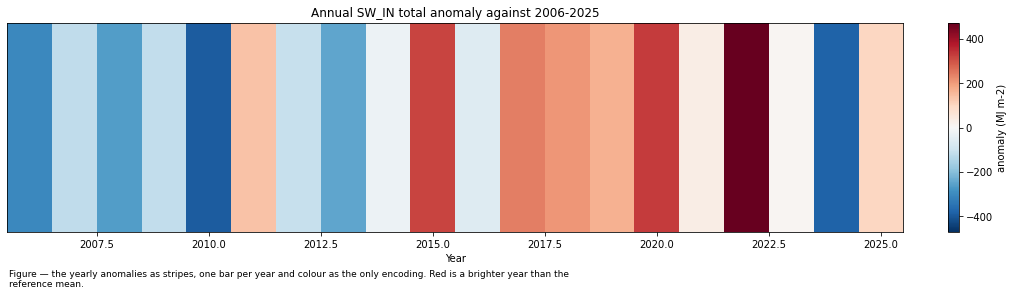

In [32]:
# The yearly anomalies as stripes: the same numbers as the bar plot above, in the form the figure
# is usually published in. One bar per year, no axis, colour is the whole message.
_anomaly = yt - yt.loc[REFERENCE_START_YEAR:REFERENCE_END_YEAR].mean()
_absmax = _anomaly.abs().max()
_cmap = plt.get_cmap('RdBu_r')
_norm = Normalize(vmin=-_absmax, vmax=_absmax)

fig, ax = plt.subplots(figsize=(14, 4), dpi=72, layout="constrained")
ax.bar(_anomaly.index, height=1.0, width=1.0, color=_cmap(_norm(_anomaly.to_numpy())))
ax.set_xlim(_anomaly.index.min() - 0.5, _anomaly.index.max() + 0.5)
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_xlabel("Year")
ax.set_title(f"Annual {var} total anomaly against {REFERENCE_START_YEAR}-{REFERENCE_END_YEAR}")
fig.colorbar(plt.cm.ScalarMappable(norm=_norm, cmap=_cmap), ax=ax, label="anomaly (MJ m-2)")
figcap(fig, f"the yearly anomalies as stripes, one bar per year and colour as the only encoding. "
            f"Red is a brighter year than the reference mean.")
fig.show()


## Trends


annual total: Theil-Sen +217.5 per decade (95 % interval +36.75 to +428.7), Kendall tau +0.39, p = 0.0164
annual clearness index: Theil-Sen +0.02319 per decade (95 % interval +0.004002 to +0.04591), Kendall tau +0.39, p = 0.0164


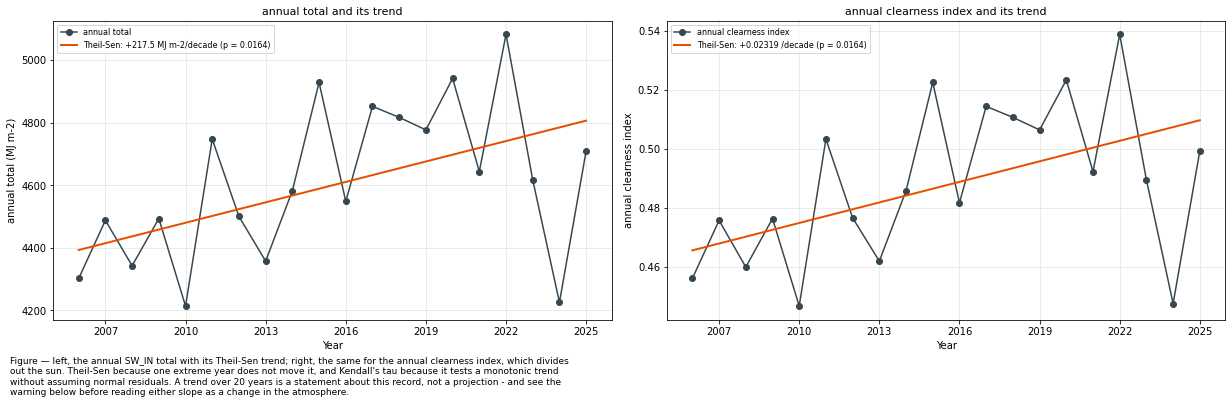

In [33]:
# Trend of the annual totals, and of the annual clearness index beside it. The second is the one
# to read: the first can move because the sky changed or because the sensor did, and the clearness
# index at least removes the astronomy. Neither separates the atmosphere from the instrument, and
# the drift documented in notebook 01 is of the same order as the trend, which the note below says.
fig, axs = plt.subplots(ncols=2, figsize=(17, 5.5), dpi=72, layout="constrained")
_fits = {}
for _ax, _s, _label, _unit in [(axs[0], yt, "annual total", "MJ m-2"),
                               (axs[1], kt_year, "annual clearness index", "")]:
    _fit = trend(_s)
    _fits[_label] = _fit
    _ax.plot(_s.index, _s, marker='o', color='#37474F', lw=1.5, label=_label)
    _ax.plot(_fit['fit'].index, _fit['fit'], color='#E65100', lw=2,
             label=f"Theil-Sen: {_fit['slope']:+.4g} {_unit}/decade (p = {_fit['pvalue']:.4f})")
    _ax.set_xlabel("Year")
    _ax.set_ylabel(f"{_label} ({_unit})" if _unit else _label)
    _ax.set_title(f"{_label} and its trend", fontsize=11)
    _ax.grid(alpha=0.3)
    _ax.legend(fontsize=8)
    year_axis(_ax)

for _label, _fit in _fits.items():
    print(f"{_label}: Theil-Sen {_fit['slope']:+.4g} per decade "
          f"(95 % interval {_fit['low']:+.4g} to {_fit['high']:+.4g}), "
          f"Kendall tau {_fit['tau']:+.2f}, p = {_fit['pvalue']:.4f}")

figcap(fig, f"left, the annual {var} total with its Theil-Sen trend; right, the same for the "
            f"annual clearness index, which divides out the sun. Theil-Sen because one extreme "
            f"year does not move it, and Kendall's tau because it tests a monotonic trend without "
            f"assuming normal residuals. A trend over {LAST_YEAR - FIRST_YEAR + 1} years is a "
            f"statement about this record, not a projection - and see the warning below before "
            f"reading either slope as a change in the atmosphere.")


### What the trend can and cannot be read as

The trend above and the sensor drift documented in notebook `01` are the same order of magnitude.
Neither this notebook nor any other in the stage can separate a change in the atmosphere from a
change in the instrument over this record, and the comparison is computed here rather than asserted
in prose so that it cannot go stale.


In [34]:
# The trend and the known sensor drift are the same order of magnitude, so the one must be quoted
# beside the other. This is computed rather than asserted in prose so it cannot go stale.
_span_decades = (LAST_YEAR - FIRST_YEAR + 1) / 10
_trend_pct = 100 * _fits["annual total"]['slope'] / yt.mean()
print(f"Trend of the annual total: {_trend_pct:+.2f} % per decade, "
      f"so {_trend_pct * _span_decades:+.1f} % over the {LAST_YEAR - FIRST_YEAR + 1} years here.")
print(f"Documented sensor drift:   about +3 % from 2013, developing over about three years, "
      f"unattributed and uncorrected (notebook 01, RADIATION_SENSOR_CONTINUITY).")
print()
print("The two are the same order of magnitude. Any reading of the trend above as a change in the")
print("atmosphere has to account for the instrument first, and this record cannot separate them.")
assert abs(_trend_pct * _span_decades) < 25, (
    "the trend of the annual total has grown far past anything the sensor drift could explain - "
    "the note above needs rewriting rather than leaving in place")


Trend of the annual total: +4.72 % per decade, so +9.4 % over the 20 years here.
Documented sensor drift:   about +3 % from 2013, developing over about three years, unattributed and uncorrected (notebook 01, RADIATION_SENSOR_CONTINUITY).

The two are the same order of magnitude. Any reading of the trend above as a change in the
atmosphere has to account for the instrument first, and this record cannot separate them.


</br>


# Cumulative plot


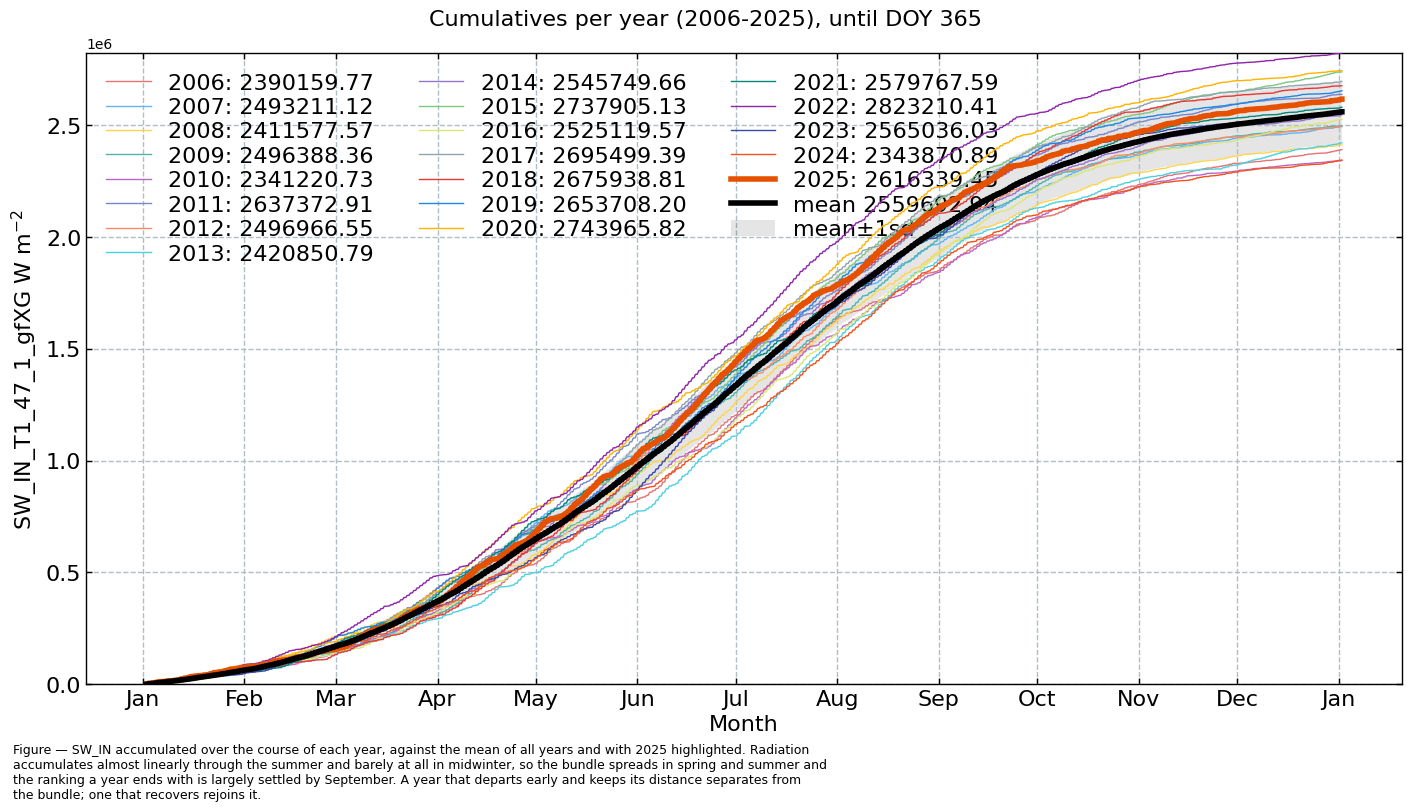

In [35]:
_cumulative = CumulativeYear(
    series=series,
    series_units=units,
    start_year=FIRST_YEAR,
    end_year=LAST_YEAR,
    show_reference=True,
    excl_years_from_reference=None,
    highlight_year=LAST_YEAR)
_cumulative.plot(highlight_year_color='#E65100')
figcap(_cumulative.fig,
       f"{var} accumulated over the course of each year, against the mean of all years and with "
       f"{LAST_YEAR} highlighted. Radiation accumulates almost linearly through the summer and "
       f"barely at all in midwinter, so the bundle spreads in spring and summer and the ranking a "
       f"year ends with is largely settled by September. A year that departs early and keeps its "
       f"distance separates from the bundle; one that recovers rejoins it.")


</br>


# Comparison with the MeteoSwiss reference station

MeteoSwiss Lägern is 2.5 km from the tower on the same ridge, operated by a different institution.

::: {.callout-important title="The reference itself changed in October 2010"}

That station's radiation instrumentation was rebuilt on 6 October 2010 — its diffuse-radiation
channel begins on exactly that timestamp — and its global radiation steps by about 5 %. The change
is at the reference, not at the tower: the two tower sensors and NABEL's all step against it
together and not against each other, which is established in
`30_PRODUCTS/RADIATION_SENSOR_CONTINUITY.ipynb`.

Everything below therefore **splits at that date rather than averaging across it**, and no
difference between this product and MeteoSwiss Lägern may be read as evidence about the tower
across it.

:::


In [36]:
# The reference product is written by 10_METEO/10_REFERENCE and is stored on TIMESTAMP_END, so it
# is shifted onto the product's TIMESTAMP_MIDDLE before anything is compared.
_ref_raw = pd.read_parquet(REFPATH)[[REFCOL]]
_ref_raw.index = _ref_raw.index - pd.Timedelta(minutes=15)
_ref_raw.index.name = df.index.name

ref = pd.DataFrame({
    'tower': series_measured,       # measured records only, so no model enters the comparison
    'reference': _ref_raw[REFCOL],
    'potential': POTRAD,
}).dropna()

# The alignment is proved rather than assumed, as in the product notebooks.
_scores = {}
for _off in (-1, 0, 1):
    _j = pd.concat([ref['tower'].rename('t'), ref['reference'].shift(_off).rename('r')],
                   axis=1).dropna()
    _j = _j[_j['r'] > 20]
    _scores[_off] = _j['t'].corr(_j['r'])
assert max(_scores, key=_scores.get) == 0, f"the reference is mis-aligned: {_scores}"
print(f"reference aligned (daytime correlation at offset 0: {_scores[0]:.4f})")

# Comparisons are ratios, and only on well-lit half-hours: at low sun the ratio between two sites
# is dominated by their horizons rather than by anything about either instrument.
ref = ref[ref['potential'] > 300]
ref['ratio'] = ref['tower'] / ref['reference']
ref = ref[(ref['tower'] > 50) & (ref['reference'] > 50)]
print(f"well-lit half-hours compared: {len(ref):,}, "
      f"{ref.index[0]:%Y-%m-%d} to {ref.index[-1]:%Y-%m-%d}")


reference aligned (daytime correlation at offset 0: 0.9648)
well-lit half-hours compared: 120,720, 2006-01-01 to 2025-12-31


## The ratio over the record


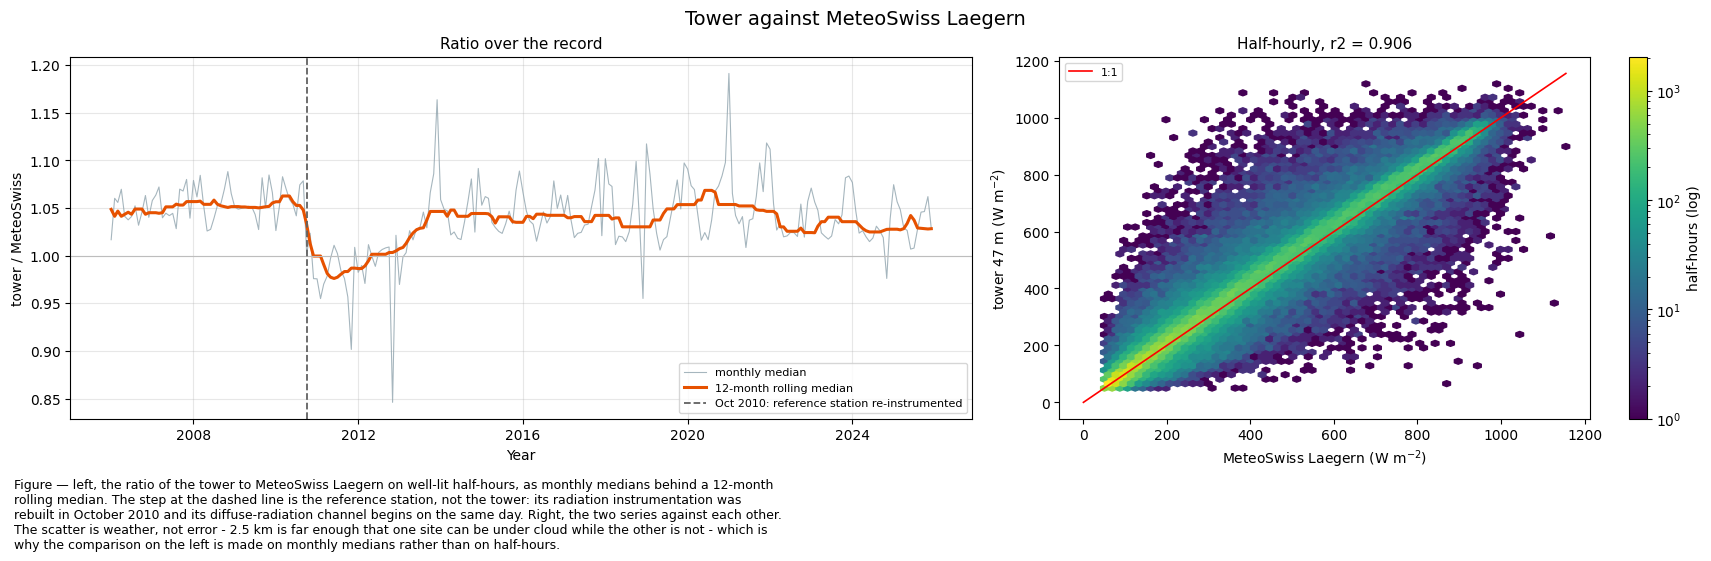

In [37]:
# The ratio over the record, with the October 2010 change at the reference station marked. The
# comparison is split there rather than averaged across it: that station's radiation
# instrumentation was rebuilt and its global radiation steps by about 5 %, which is a property of
# the reference and not of the tower (see RADIATION_SENSOR_CONTINUITY).
_monthly_ratio = ref['ratio'].resample('MS').median()
_n = ref['ratio'].resample('MS').count()
_monthly_ratio = _monthly_ratio[_n >= 50]

fig, axs = plt.subplots(ncols=2, figsize=(17, 5.5), dpi=100, layout="constrained",
                        width_ratios=[1.7, 1])
fig.suptitle("Tower against MeteoSwiss Laegern", fontsize=14)

axs[0].plot(_monthly_ratio.index, _monthly_ratio, color='#90A4AE', lw=0.8, alpha=0.8,
            label="monthly median")
axs[0].plot(_monthly_ratio.index, _monthly_ratio.rolling(12, center=True, min_periods=6).median(),
            color='#E65100', lw=2.2, label="12-month rolling median")
axs[0].axhline(1.0, color='#BDBDBD', lw=0.8)
axs[0].axvline(pd.Timestamp(f'{REF_STEP_YEAR - 1}-10-06'), color='#616161', lw=1.3, ls='--',
               label="Oct 2010: reference station re-instrumented")
axs[0].set_xlabel("Year")
axs[0].set_ylabel("tower / MeteoSwiss")
axs[0].set_title("Ratio over the record", fontsize=11)
axs[0].grid(alpha=0.3)
axs[0].legend(fontsize=8)

_hb = axs[1].hexbin(ref['reference'], ref['tower'], gridsize=60, mincnt=1, bins='log',
                    cmap='viridis')
_lim = [0, float(max(ref['tower'].max(), ref['reference'].max()))]
axs[1].plot(_lim, _lim, 'r-', lw=1.2, label='1:1')
axs[1].set_xlabel(f"MeteoSwiss Laegern ({units})")
axs[1].set_ylabel(f"tower 47 m ({units})")
axs[1].set_title(f"Half-hourly, r2 = {ref['tower'].corr(ref['reference']) ** 2:.3f}", fontsize=11)
axs[1].legend(fontsize=8)
fig.colorbar(_hb, ax=axs[1], label="half-hours (log)")

figcap(fig, f"left, the ratio of the tower to MeteoSwiss Laegern on well-lit half-hours, as "
            f"monthly medians behind a 12-month rolling median. The step at the dashed line is "
            f"the reference station, not the tower: its radiation instrumentation was rebuilt in "
            f"October 2010 and its diffuse-radiation channel begins on the same day. Right, the "
            f"two series against each other. The scatter is weather, not error - 2.5 km is far "
            f"enough that one site can be under cloud while the other is not - which is why the "
            f"comparison on the left is made on monthly medians rather than on half-hours.")


## The two eras of the reference


In [38]:
# THREE windows, not two. The obvious split - before and after October 2010 - measures the
# reference station's step and the tower's own 2013 departure at once, and the two act in opposite
# directions on this ratio and partly cancel: taken that way the step comes out at about half its
# size, which is what a first version of this cell reported.
#
# 2011-2012 are the only two complete years that are after the reference station changed and
# before the tower sensor started drifting, so they are the window in which the reference step can
# be measured on its own. The last row carries both changes and is here for completeness.
TOWER_DRIFT_YEAR = 2013  # when the tower sensor begins departing (RADIATION_SENSOR_CONTINUITY)
WINDOWS = [
    (f'{FIRST_YEAR}-{REF_STEP_YEAR - 1}', FIRST_YEAR, REF_STEP_YEAR - 1,
     'before the reference station changed'),
    (f'{REF_STEP_YEAR}-{TOWER_DRIFT_YEAR - 1}', REF_STEP_YEAR, TOWER_DRIFT_YEAR - 1,
     'after it, before the tower sensor drifts'),
    (f'{TOWER_DRIFT_YEAR}-{LAST_YEAR}', TOWER_DRIFT_YEAR, LAST_YEAR,
     'both changes present'),
]
_rows = []
for _label, _y0, _y1, _what in WINDOWS:
    _sel = ref[(ref.index.year >= _y0) & (ref.index.year <= _y1)]
    _rows.append({'period': _label, 'what it holds': _what, 'half-hours': len(_sel),
                  'median ratio': _sel['ratio'].median(),
                  'mean tower (W m-2)': _sel['tower'].mean(),
                  'mean reference (W m-2)': _sel['reference'].mean()})
ref_eras = pd.DataFrame(_rows).set_index('period')
ref_eras['departure from 1 (%)'] = 100 * (ref_eras['median ratio'] - 1)

display(styled(ref_eras,
               caption=f"the tower against MeteoSwiss Laegern in three windows. The first two "
                       f"differ only by the reference station's October 2010 rebuild, which is "
                       f"what isolates it; the third also carries the tower's own departure from "
                       f"{TOWER_DRIFT_YEAR}, which acts the other way and partly cancels it. No "
                       f"row is a calibration statement about this product",
               fmt={'half-hours': "{:.0f}", 'median ratio': "{:.4f}",
                    'mean tower (W m-2)': "{:.1f}", 'mean reference (W m-2)': "{:.1f}",
                    'departure from 1 (%)': "{:+.2f}"}, cmap=None))

_clean = ref_eras['median ratio'].iloc[1] / ref_eras['median ratio'].iloc[0] - 1
_muddled = ref_eras['median ratio'].iloc[2] / ref_eras['median ratio'].iloc[0] - 1
print(f"Reference station's step, measured on the clean window:  {100 * _clean:+.2f} %")
print(f"The same comparison against {TOWER_DRIFT_YEAR}-{LAST_YEAR}:            "
      f"{100 * _muddled:+.2f} %  <- two changes at once, do not use")

assert abs(_clean) > 0.03, (
    "the October 2010 change at the reference station has disappeared from the window that "
    "isolates it - either the reference product was rebuilt or the split years are wrong, and the "
    "text around this cell must be re-derived rather than relaxed")
assert abs(_clean) > abs(_muddled), (
    "the two changes no longer partly cancel, which is the reason this table has three rows "
    "rather than two - re-check which years hold which change")


Table — the tower against MeteoSwiss Laegern in three windows. The first two differ only by the
reference station's October 2010 rebuild, which is what isolates it; the third also carries the
tower's own departure from 2013, which acts the other way and partly cancels it. No row is a
calibration statement about this product



,what it holds,half-hours,median ratio,mean tower (W m-2),mean reference (W m-2),departure from 1 (%)
period,,,,,,
2006-2010,before the reference station changed,29826,1.0516,381.0,361.6,+5.16
2011-2012,"after it, before the tower sensor drifts",11714,0.9901,398.5,399.6,-0.99
2013-2025,both changes present,79180,1.0348,407.4,392.5,+3.48


Reference station's step, measured on the clean window:  -5.85 %
The same comparison against 2013-2025:            -1.60 %  <- two changes at once, do not use


</br>


# Sensor continuity

The product exports **one value column and no homogenised variant**. That is a claim: it says the
record does not step at either of its two hardware changes — the January 2016 logger replacement
and the December 2021 replacement of the radiometer itself. The claim is re-derived here and
asserted, so a re-run of this notebook fails if it ever stops being true.

The 2013 departure of the sensor from its references, about 3 % and unattributed, is **not**
corrected in the product and is not tested here; it has no date to test at. It is documented in
`docs/Meteo_Data_SW_IN.md` and in `30_PRODUCTS/RADIATION_SENSOR_CONTINUITY.ipynb`.


In [39]:
# The two hardware changes this product is asserted to be homogeneous across, re-derived here. The
# overview is read on its own, so it repeats the check rather than pointing at notebook 01 for it.
#
# Ratios against the reference, month-matched and on well-lit April-September half-hours only, for
# the reasons given in About. The 2016 window is taken entirely inside the reference station's
# later era, so its own October 2010 step cannot enter.
_summer = ref[ref.index.month.isin([4, 5, 6, 7, 8, 9])]
_m = _summer['ratio'].groupby([_summer.index.year, _summer.index.month]).median()
_m.index.names = ['year', 'month']
_n = _summer['ratio'].groupby([_summer.index.year, _summer.index.month]).count()
_ratio_year = _m[_n >= 100].groupby(level=0).mean()


def _change_across(year, span=3):
    """Month-matched percentage change of the ratio across `year`, `span` years either side."""
    _pre = _ratio_year.reindex(range(year - span, year)).dropna()
    _post = _ratio_year.reindex(range(year + 1, year + 1 + span)).dropna()
    if len(_pre) < 2 or len(_post) < 2:
        return float('nan')
    return 100 * (_post.mean() / _pre.mean() - 1)


CHANGES = {2016: "logger replaced, sensor unchanged (CNR1 throughout)",
           2022: "radiometer replaced, CNR1 -> CNR4, and the mst/diive screening splice"}
_rows = [{'year': _y, 'what happened': _w, 'change in the ratio (%)': _change_across(_y)}
         for _y, _w in CHANGES.items()]
continuity = pd.DataFrame(_rows).set_index('year')
_others = pd.Series({_y: _change_across(_y) for _y in _ratio_year.index
                     if _y not in CHANGES}).dropna()
continuity['median |change| elsewhere (%)'] = _others.abs().median()
continuity['largest |change| elsewhere (%)'] = _others.abs().max()

display(styled(continuity,
               caption=f"the change in the tower-to-reference ratio across each hardware change, "
                       f"against what the same measurement finds at every other year of the "
                       f"record. Both changes are smaller than an ordinary year's variation, "
                       f"which is what the single value column of this product rests on",
               fmt={'change in the ratio (%)': "{:+.2f}",
                    'median |change| elsewhere (%)': "{:.2f}",
                    'largest |change| elsewhere (%)': "{:.2f}"}, cmap=None))

# The assertion the single value column rests on. It is the overview's own copy of the guard in
# notebook 01, and it fails here too if the product ever stops being homogeneous.
EVENT_THRESHOLD = 2.0
for _year, _row in continuity.iterrows():
    _c = _row['change in the ratio (%)']
    assert abs(_c) < EVENT_THRESHOLD, (
        f"{var} changes by {_c:+.2f} % across the {_year} hardware change, past the "
        f"{EVENT_THRESHOLD} % at which this record counts an event. The product exports one value "
        f"column on the grounds that it does not step at either change; that is no longer true "
        f"and both this notebook and notebook 01 must be re-derived")
print(f"\nNeither hardware change moves the series by as much as {EVENT_THRESHOLD} %. The product "
      f"is exported as a single value column with no homogenised variant, and that is what "
      f"justifies it.")


Table — the change in the tower-to-reference ratio across each hardware change, against what the
same measurement finds at every other year of the record. Both changes are smaller than an ordinary
year's variation, which is what the single value column of this product rests on



,what happened,change in the ratio (%),median |change| elsewhere (%),largest |change| elsewhere (%)
year,,,,
2016,"logger replaced, sensor unchanged (CNR1 throughout)",-0.27,0.84,3.63
2022,"radiometer replaced, CNR1 -> CNR4, and the mst/diive screening splice",-0.84,0.84,3.63



Neither hardware change moves the series by as much as 2.0 %. The product is exported as a single value column with no homogenised variant, and that is what justifies it.


</br>


# Appendix: single-year detail

One figure per year, drawn only when `SHOW_PER_YEAR_DETAIL` is set in the Settings cell. It repeats
the monthly distributions year by year and is kept at the end because it is detail, not overview.


## Single years per month


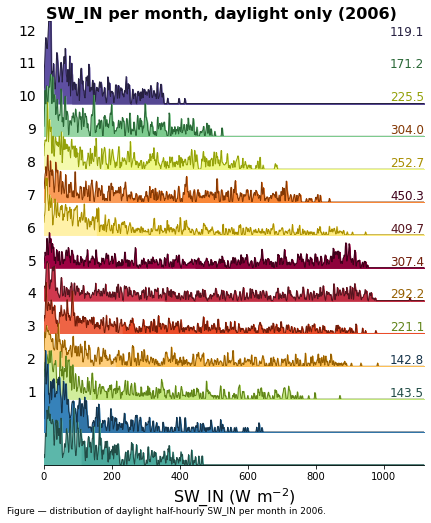

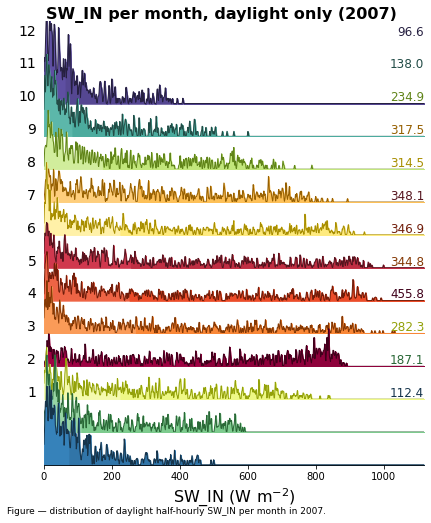

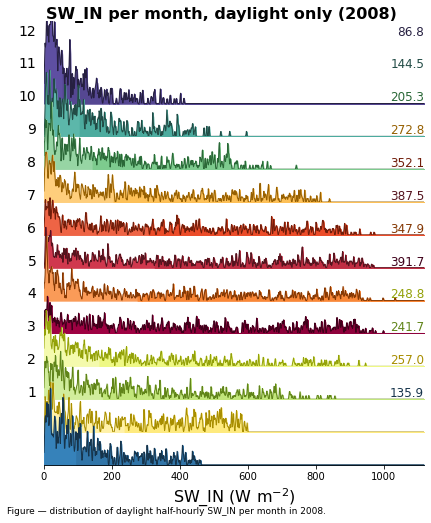

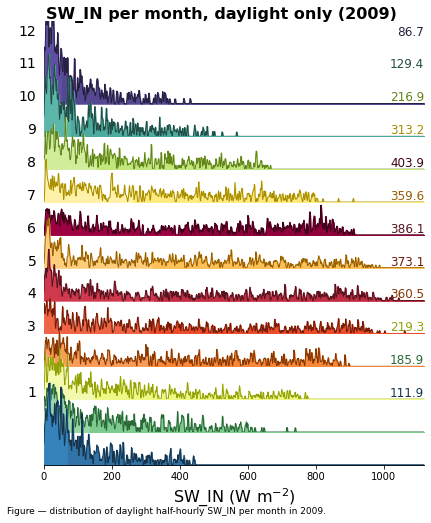

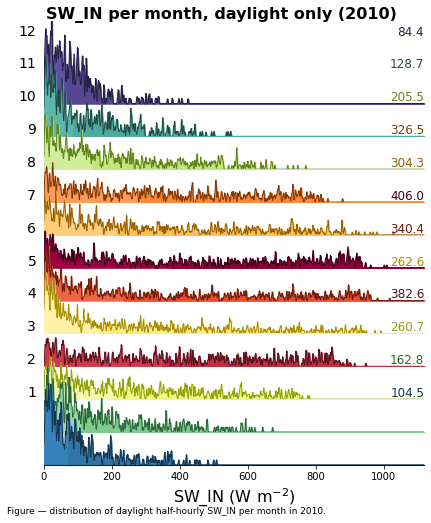

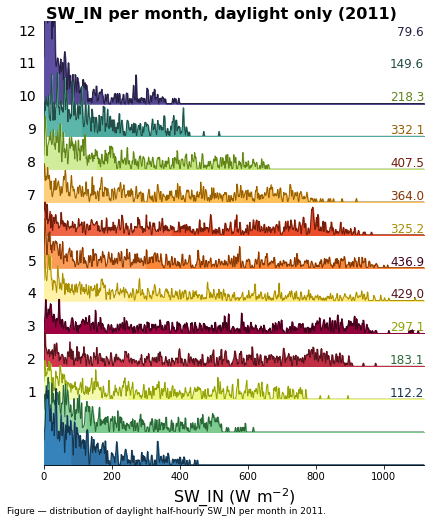

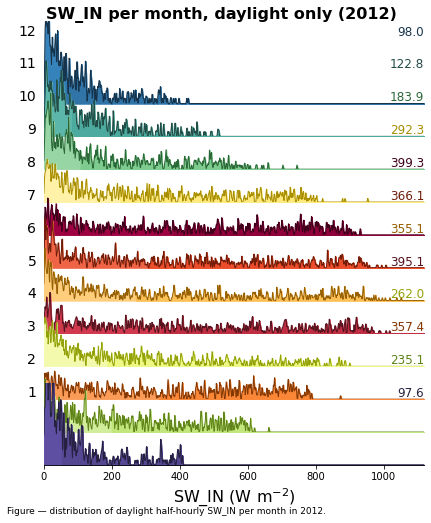

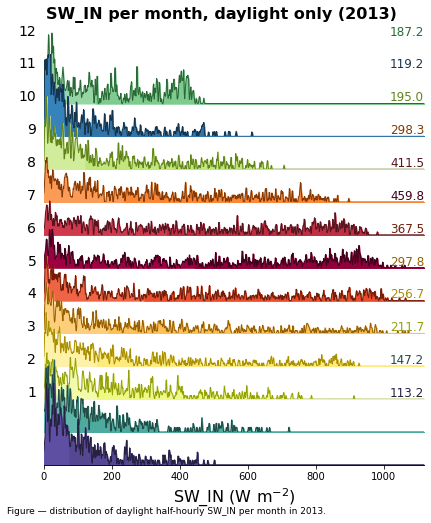

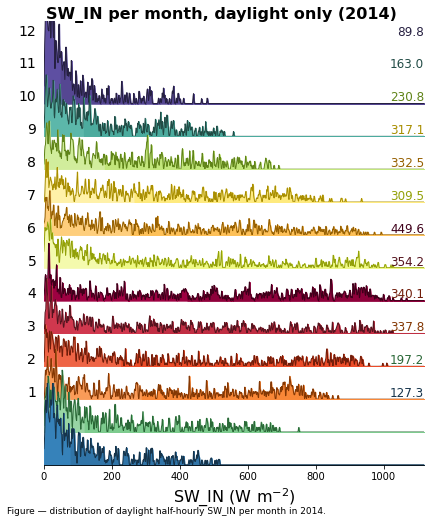

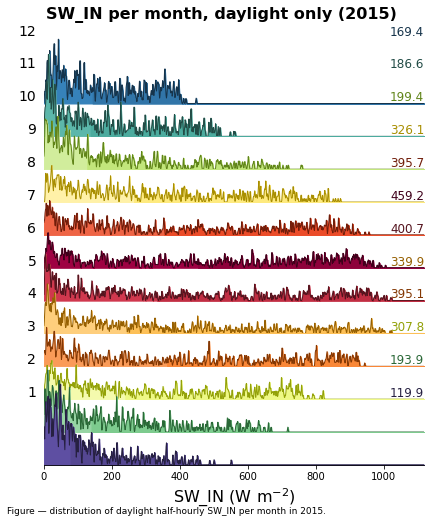

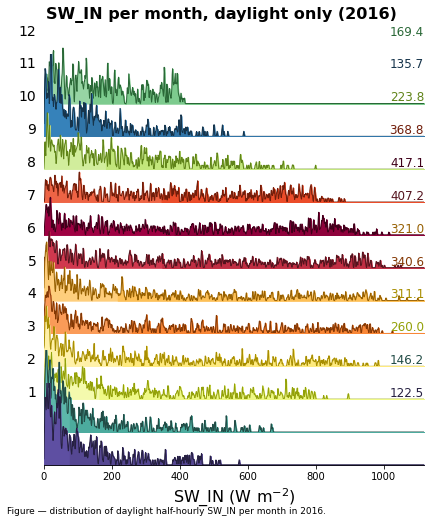

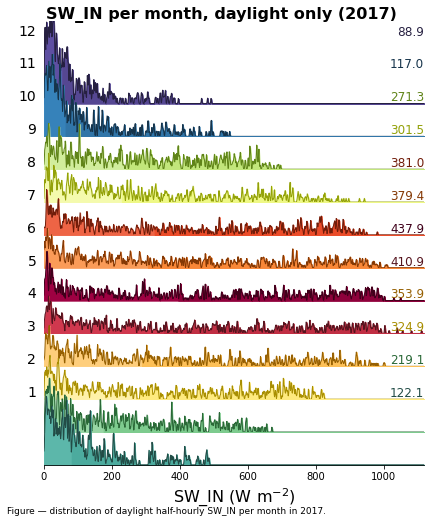

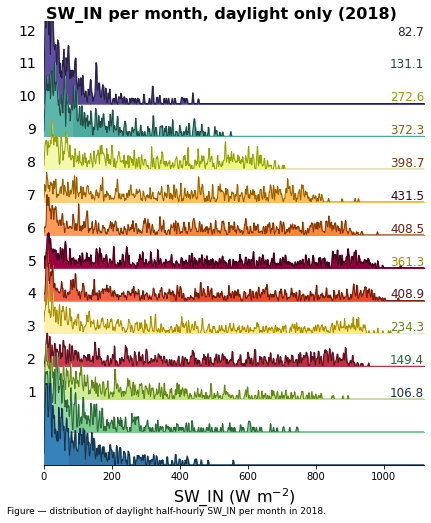

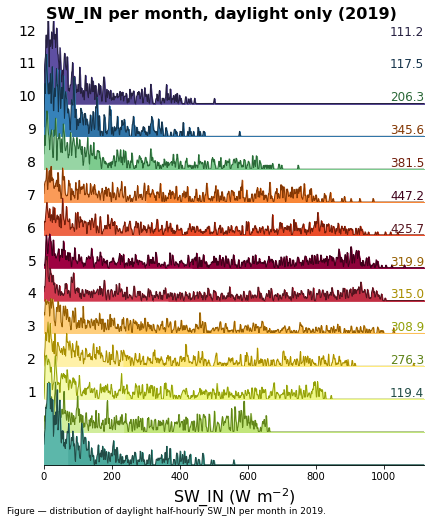

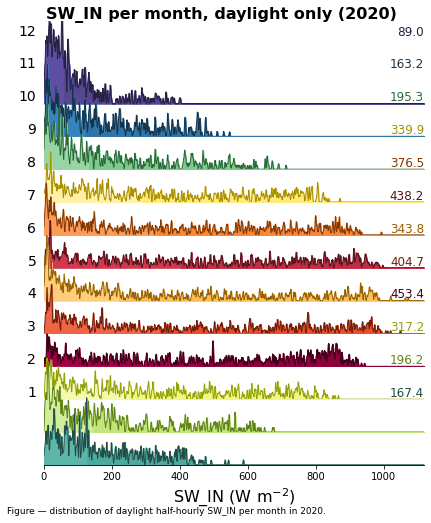

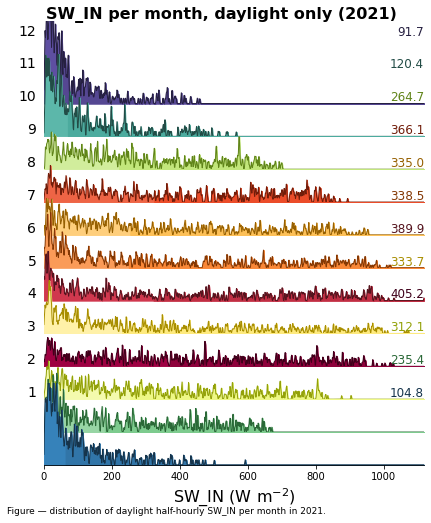

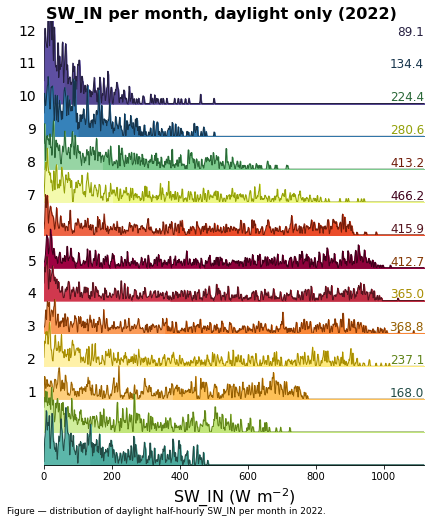

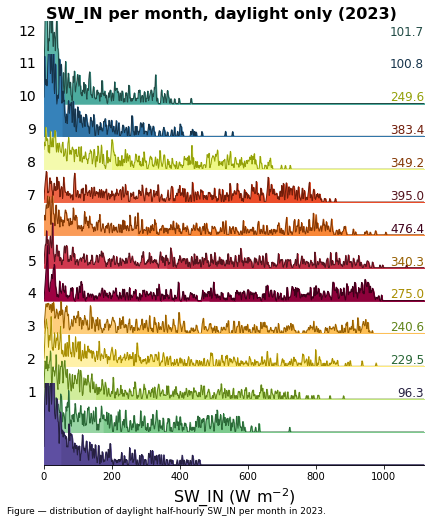

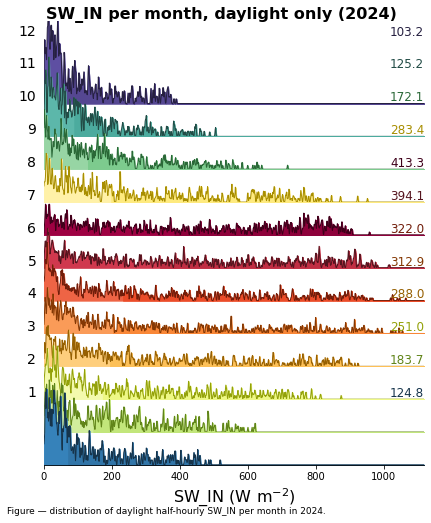

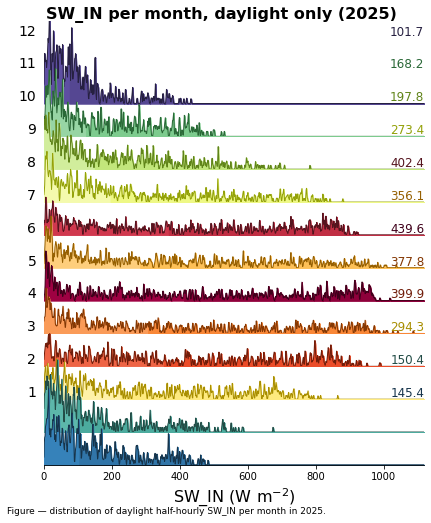

In [40]:
if SHOW_PER_YEAR_DETAIL:
    uniq_years = daylight.dropna().index.year.unique()
    for uy in uniq_years:
        series_yr = daylight.dropna()
        series_yr = series_yr.loc[series_yr.index.year == uy].copy()
        rp = dv.plotting.RidgeLinePlot(series=series_yr)
        rp.plot(
            how='monthly',
            kd_kwargs=None,
            xlim=xlim,
            ylim=[0, 0.012],
            hspace=-0.6,
            fig_width=6,
            fig_height=7,
            shade_percentile=0.5,
            show_mean_line=False,
            format_style=dv.plotting.FormatStyle(
                xlabel=xlabel, title=f"{var} per month, daylight only ({uy})"),
            fig_dpi=72,
            showplot=True,
            ascending=False
        )
        figcap(rp.fig, f"distribution of daylight half-hourly {var} per month in {uy}.")


</br>


# End of notebook


In [41]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")


Finished. 2026-07-29 00:08:57
